# Notebook 05 — Evaluation, Comparison & Policy-Facing Findings

**This is the final synthesis notebook. It produces:**
1. Classification method comparison table (supervised NLP methods vs qualitative ground truth)
2. Publication-ready figures for the thesis
3. Phrase-aware SHAP–LIME interpretability summary from Notebook 03
4. Human-code phrase evidence from Notebook 03_1 and triangulated LIME/SHAP evidence from Notebook 03
5. Domain-phrase evidence from Notebook 03_0
6. **Policy-facing findings** — consent-related problem themes in Irish maternity care

**Research questions answered here:**
- Can supervised NLP reproduce qualitative codes? (reproducibility — Cohen's κ, macro F1)
- Where does it fail and why? (interpretability — phrase-aware SHAP/LIME disagreement plus human-code phrase triangulation)
- What recurring problems do women in Ireland report about induction? (policy findings)

**Run order expected:** `00 → 01 → 02 → 03_0 → 03_1 → 03 → 04`.

**Metric boundary:** clustering metrics (NMI/ARI) are reported separately from supervised classification metrics (Cohen's κ, macro-F1, weighted-F1). They are not interchangeable.


In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import pickle, pathlib, warnings, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from sklearn.metrics import (cohen_kappa_score, f1_score, precision_score, recall_score, classification_report,
                               confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

DATA_DIR = pathlib.Path('data')
SOURCE_OUTPUT_DIR = pathlib.Path('outputs')
INTERP_OUTPUT_DIR = SOURCE_OUTPUT_DIR / 'broad_candidate_revision'
OUTPUT_DIR = INTERP_OUTPUT_DIR / 'evaluation_policy'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / 'config.pkl', 'rb') as f:
    cfg = pickle.load(f)
DECISION_CODES   = cfg['DECISION_CODES']
CODE_DEFINITIONS = cfg['CODE_DEFINITIONS']
DEVICE           = cfg['DEVICE']
CODE_NAMES       = list(DECISION_CODES.keys())
LABEL_TO_CODE    = {v: k for k, v in DECISION_CODES.items()}

dm_df  = pd.read_csv(DATA_DIR / 'decision_making.csv')
DOCS   = dm_df['response_text'].tolist()
LABELS = dm_df['label'].values
dm_df['code_name'] = dm_df['label'].map(LABEL_TO_CODE)
label_counts = dm_df['code_name'].value_counts().reindex(CODE_NAMES).fillna(0).astype(int)

REPORTABLE_SETFIT_METHOD = 'SetFit MPNet stronger semantic baseline 5-fold CV'
REPORTABLE_SETFIT_PATH = DATA_DIR / 'reportable_setfit_cv_metrics.json'

def parse_reportable_setfit_from_notebook(notebook_path, method_name, code_names):
    import re
    code_pattern = re.compile(r'^\s*(' + '|'.join(re.escape(c) for c in code_names) + r')\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)\s*$')
    summary_pattern = re.compile(r'^\s*(macro avg|weighted avg)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)\s*$')
    kappa_pattern = re.compile(r"Cohen's κ = ([0-9.]+)")
    nb = json.loads(pathlib.Path(notebook_path).read_text(encoding='utf-8'))
    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for out in cell.get('outputs', []):
            text = out.get('text', '')
            if isinstance(text, list):
                text = ''.join(text)
            if not text or method_name not in text or 'precision    recall  f1-score   support' not in text:
                continue
            per_class = {}
            macro_summary = None
            weighted_summary = None
            kappa = np.nan
            for line in text.splitlines():
                m = code_pattern.match(line)
                if m:
                    per_class[m.group(1)] = {
                        'precision': round(float(m.group(2)), 3),
                        'recall': round(float(m.group(3)), 3),
                        'f1-score': round(float(m.group(4)), 3),
                        'support': int(m.group(5)),
                    }
                    continue
                m = summary_pattern.match(line)
                if m:
                    summary = {
                        'precision': round(float(m.group(2)), 3),
                        'recall': round(float(m.group(3)), 3),
                        'f1': round(float(m.group(4)), 3),
                        'support': int(m.group(5)),
                    }
                    if m.group(1) == 'macro avg':
                        macro_summary = summary
                    else:
                        weighted_summary = summary
                    continue
                m = kappa_pattern.search(line)
                if m:
                    kappa = round(float(m.group(1)), 3)
            if per_class and macro_summary and weighted_summary:
                return {
                    'summary': {
                        'Method': method_name,
                        'Task': '5-class decision-making',
                        "Cohen's κ": kappa,
                        'κ agreement': ('poor' if kappa < 0.20 else
                                        'fair' if kappa < 0.40 else
                                        'moderate' if kappa < 0.60 else
                                        'substantial' if kappa < 0.80 else 'near-perfect'),
                        'Macro Precision': macro_summary['precision'],
                        'Macro Recall': macro_summary['recall'],
                        'Macro F1': macro_summary['f1'],
                        'Weighted Precision': weighted_summary['precision'],
                        'Weighted Recall': weighted_summary['recall'],
                        'Weighted F1': weighted_summary['f1'],
                    },
                    'per_class': per_class,
                    'source': 'notebook02_outputs',
                }
    return None

def load_reportable_setfit_cv():
    if REPORTABLE_SETFIT_PATH.exists():
        with open(REPORTABLE_SETFIT_PATH, 'r', encoding='utf-8') as f:
            return json.load(f)
    recovered = parse_reportable_setfit_from_notebook(pathlib.Path('02_classification.ipynb'), REPORTABLE_SETFIT_METHOD, CODE_NAMES)
    if recovered is not None:
        with open(REPORTABLE_SETFIT_PATH, 'w', encoding='utf-8') as f:
            json.dump(recovered, f, indent=2)
    return recovered

reportable_setfit_cv = load_reportable_setfit_cv()


with open(DATA_DIR / 'classification_results.pkl', 'rb') as f:
    clf_results = pickle.load(f)

with open(DATA_DIR / 'bertopic_results.pkl', 'rb') as f:
    bt_results = pickle.load(f)

DOMAIN_PHRASE_PATH = SOURCE_OUTPUT_DIR / 'domain_phrase_candidates.csv'
if DOMAIN_PHRASE_PATH.exists():
    domain_phrase_map = pd.read_csv(DOMAIN_PHRASE_PATH)
    if 'phrase_len' not in domain_phrase_map.columns:
        domain_phrase_map['phrase_len'] = domain_phrase_map['phrase'].astype(str).str.split().str.len()
    domain_phrase_map = domain_phrase_map[domain_phrase_map['phrase_len'].between(2, 4)].copy()
    HAS_DOMAIN_PHRASES = True
else:
    domain_phrase_map = pd.DataFrame(columns=['code_name', 'phrase', 'evidence_score'])
    HAS_DOMAIN_PHRASES = False
    print('Broad domain phrase candidates not found — run notebook 03_0 first.')

try:
    with open(DATA_DIR / 'interpretability_results_broad_candidate_revision.pkl', 'rb') as f:
        interp_results = pickle.load(f)
    HAS_INTERP = True
except Exception as e:
    interp_results = {}
    HAS_INTERP = False
    print(f'Interpretability results not loadable — run notebook 03 in the thesis environment first. Reason: {type(e).__name__}: {e}')

print(f'Decision-making responses loaded: {len(dm_df)}')
print(f'Loaded results from {len(clf_results)} classification methods')
print(f'Broad domain phrase candidates: {HAS_DOMAIN_PHRASES} ({len(domain_phrase_map)} phrase-code rows)')
TRIANGULATION_PATH = INTERP_OUTPUT_DIR / 'triangulated_phrase_evidence.csv'
TRIANGULATION_TOP_PATH = INTERP_OUTPUT_DIR / 'triangulated_phrase_evidence_top_by_response.csv'
TRIANGULATION_PATTERN_PATH = INTERP_OUTPUT_DIR / 'triangulation_pattern_summary.csv'

if TRIANGULATION_PATH.exists():
    triangulated_phrase_evidence_df = pd.read_csv(TRIANGULATION_PATH)
    triangulated_top_by_response_df = pd.read_csv(TRIANGULATION_TOP_PATH) if TRIANGULATION_TOP_PATH.exists() else pd.DataFrame()
    triangulation_pattern_summary = pd.read_csv(TRIANGULATION_PATTERN_PATH) if TRIANGULATION_PATTERN_PATH.exists() else pd.DataFrame()
    HAS_TRIANGULATION = True
elif HAS_INTERP and interp_results.get('triangulated_phrase_evidence') is not None:
    triangulated_phrase_evidence_df = interp_results['triangulated_phrase_evidence'].copy()
    triangulated_top_by_response_df = interp_results.get('triangulated_top_by_response', pd.DataFrame()).copy()
    triangulation_pattern_summary = interp_results.get('triangulation_pattern_summary', pd.DataFrame()).copy()
    HAS_TRIANGULATION = True
else:
    triangulated_phrase_evidence_df = pd.DataFrame()
    triangulated_top_by_response_df = pd.DataFrame()
    triangulation_pattern_summary = pd.DataFrame()
    HAS_TRIANGULATION = False

print(f'Interpretability results: {HAS_INTERP}')
print(f'Triangulated phrase evidence: {HAS_TRIANGULATION} ({len(triangulated_phrase_evidence_df)} phrase rows)')
print('\nWorking label counts used by notebooks:')
print(label_counts.to_string())

Decision-making responses loaded: 278
Loaded results from 7 classification methods
Broad domain phrase candidates: True (1109 phrase-code rows)
Interpretability results: True
Triangulated phrase evidence: True (1305 phrase rows)

Working label counts used by notebooks:
code_name
voluntary_informed     36
feeling_pressured      80
insufficient_info     145
too_much_info           9
no_consent              8


## 1. Classification and clustering method comparison tables

In [2]:
# ── Build classification and clustering comparison tables ────────────────────
classification_rows = []
for method_name, result in clf_results.items():
    y_true = np.asarray(result['true'])
    y_pred = np.asarray(result['preds'])

    # Keep only decision-making-code results from the current notebook 02 pipeline.
    if len(y_true) != len(LABELS):
        continue

    kappa              = cohen_kappa_score(y_true, y_pred)
    macro_precision    = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    macro_recall       = recall_score(y_true, y_pred, average='macro',       zero_division=0)
    macro_f1           = f1_score(y_true, y_pred, average='macro',           zero_division=0)
    weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    weighted_recall    = recall_score(y_true, y_pred, average='weighted',    zero_division=0)
    weighted_f1        = f1_score(y_true, y_pred, average='weighted',        zero_division=0)

    kappa_label = ('poor'          if kappa < 0.20 else
                   'fair'          if kappa < 0.40 else
                   'moderate'      if kappa < 0.60 else
                   'substantial'   if kappa < 0.80 else 'near-perfect')

    classification_rows.append({
        'Method':           method_name,
        'Task':             '5-class decision-making',
        "Cohen's κ":        round(kappa,       3),
        'κ agreement':      kappa_label,
        'Macro Precision':  round(macro_precision,    3),
        'Macro Recall':     round(macro_recall,       3),
        'Macro F1':         round(macro_f1,           3),
        'Weighted Precision': round(weighted_precision, 3),
        'Weighted Recall':    round(weighted_recall,    3),
        'Weighted F1':        round(weighted_f1,        3),
    })

if reportable_setfit_cv is not None and not any(row['Method'] == REPORTABLE_SETFIT_METHOD for row in classification_rows):
    classification_rows.append(reportable_setfit_cv['summary'].copy())

comparison_df = pd.DataFrame(classification_rows)
comparison_df.insert(0, 'Evaluation family', 'supervised classification')
comparison_df['Metric boundary note'] = 'classification metrics only; not comparable with clustering NMI/ARI'
comparison_df.to_csv(OUTPUT_DIR / 'method_comparison_table.csv', index=False)

assignments_identical = bool(bt_results.get('guided_assignments_identical_to_unsupervised', np.array_equal(bt_results.get('topics_unsupervised', []), bt_results.get('topics_guided', []))))
clustering_rows = [{
    'Method': 'BERTopic unsupervised',
    'Task': 'topic clustering vs human consent codes',
    'NMI': round(float(bt_results.get('nmi_unsup', np.nan)), 3),
    'ARI': round(float(bt_results.get('ari_unsup', np.nan)), 3),
    'Interpretation': 'cluster-code alignment only; not classification performance',
}]
if not assignments_identical:
    clustering_rows.append({
        'Method': 'BERTopic guided assignment-changing variant', 'Task': 'topic clustering vs human consent codes',
        'NMI': round(float(bt_results.get('nmi_guided', np.nan)), 3), 'ARI': round(float(bt_results.get('ari_guided', np.nan)), 3),
        'Interpretation': 'cluster-code alignment only; not classification performance',
    })
else:
    clustering_rows[0]['Interpretation'] += '; guided keywords changed representation only, assignments were identical'
clustering_df = pd.DataFrame(clustering_rows)
clustering_df.insert(0, 'Evaluation family', 'topic clustering alignment')
clustering_df['Metric boundary note'] = 'NMI/ARI cluster-code alignment only; not classification performance'
clustering_df.to_csv(OUTPUT_DIR / 'clustering_alignment_table.csv', index=False)

print('\n' + '='*80)
print('  CLASSIFICATION METHOD COMPARISON TABLE')
print('='*80)
print(comparison_df.to_string(index=False))
print('='*80)
print('\n' + '='*80)
print('  CLUSTERING ALIGNMENT TABLE')
print('='*80)
print(clustering_df.to_string(index=False))
print('='*80)
print('\nNote: BERTopic NMI/ARI are clustering-alignment metrics and are intentionally kept out of the classification table.')



  CLASSIFICATION METHOD COMPARISON TABLE
        Evaluation family                                            Method                    Task  Cohen's κ κ agreement  Macro Precision  Macro Recall  Macro F1  Weighted Precision  Weighted Recall  Weighted F1                                                Metric boundary note
supervised classification                  VADER heuristic (decision codes) 5-class decision-making      0.078        poor            0.261         0.226     0.194               0.469            0.360        0.353 classification metrics only; not comparable with clustering NMI/ARI
supervised classification        Cardiff RoBERTa (decision codes heuristic) 5-class decision-making      0.112        poor            0.318         0.279     0.280               0.464            0.460        0.447 classification metrics only; not comparable with clustering NMI/ARI
supervised classification                 Hartmann Emotion (decision codes) 5-class decision-making      0.109  

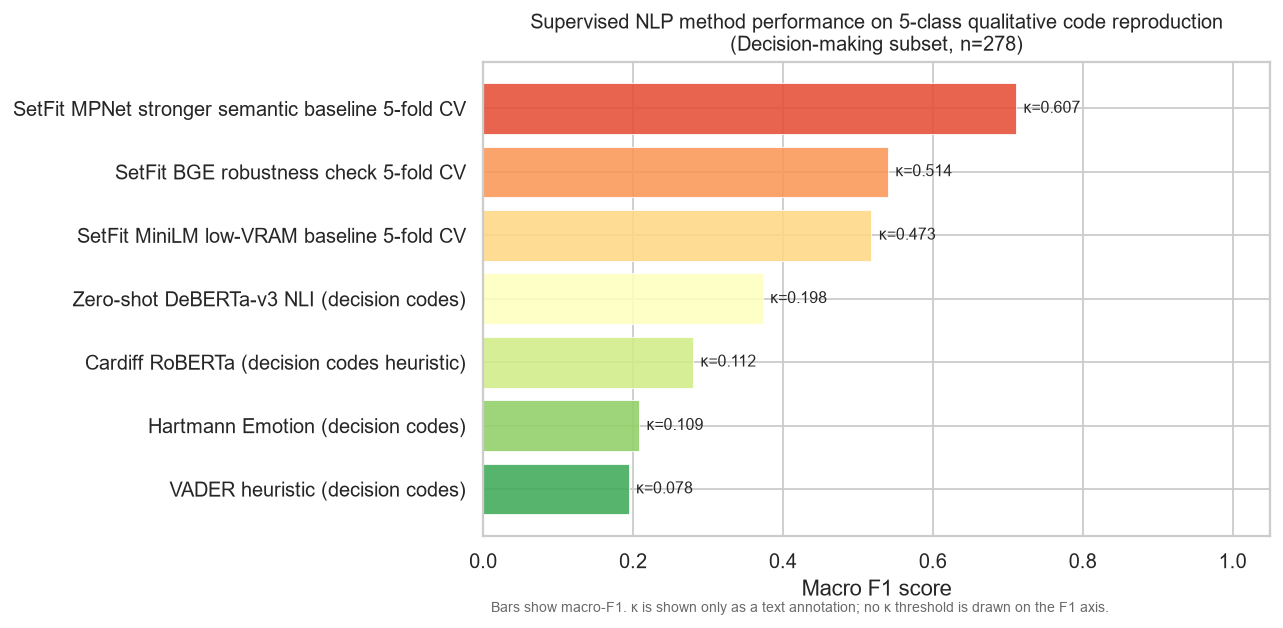

Saved: fig1_method_comparison.pdf + .png


In [3]:
# ── Figure 1: Macro F1 comparison bar chart ───────────────────────────────────
five_class_sorted = (
    comparison_df[comparison_df['Task'].eq('5-class decision-making')]
    .sort_values('Macro F1', ascending=True)
    .reset_index(drop=True)
)
five_class_plot = five_class_sorted.copy()
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(five_class_plot)))
kcol = "Cohen's κ"   # avoid backslashes inside f-string {…} (SyntaxError on Python <3.12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(five_class_plot['Method'], five_class_plot['Macro F1'],
               color=colors[::-1], alpha=0.88, edgecolor='white', linewidth=0.5)
for bar, (_, row) in zip(bars, five_class_plot.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"κ={row[kcol]}", va='center', fontsize=9)
ax.set_xlabel('Macro F1 score')
ax.set_xlim(0, 1.05)
ax.set_title('Supervised NLP method performance on 5-class qualitative code reproduction\n'
             '(Decision-making subset, n=278)', fontsize=11)
ax.text(0.01, -0.16, 'Bars show macro-F1. κ is shown only as a text annotation; no κ threshold is drawn on the F1 axis.',
        transform=ax.transAxes, fontsize=8, color='dimgray')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_method_comparison.pdf', bbox_inches='tight')  # PDF for LaTeX
plt.savefig(OUTPUT_DIR / 'fig1_method_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig1_method_comparison.pdf + .png')


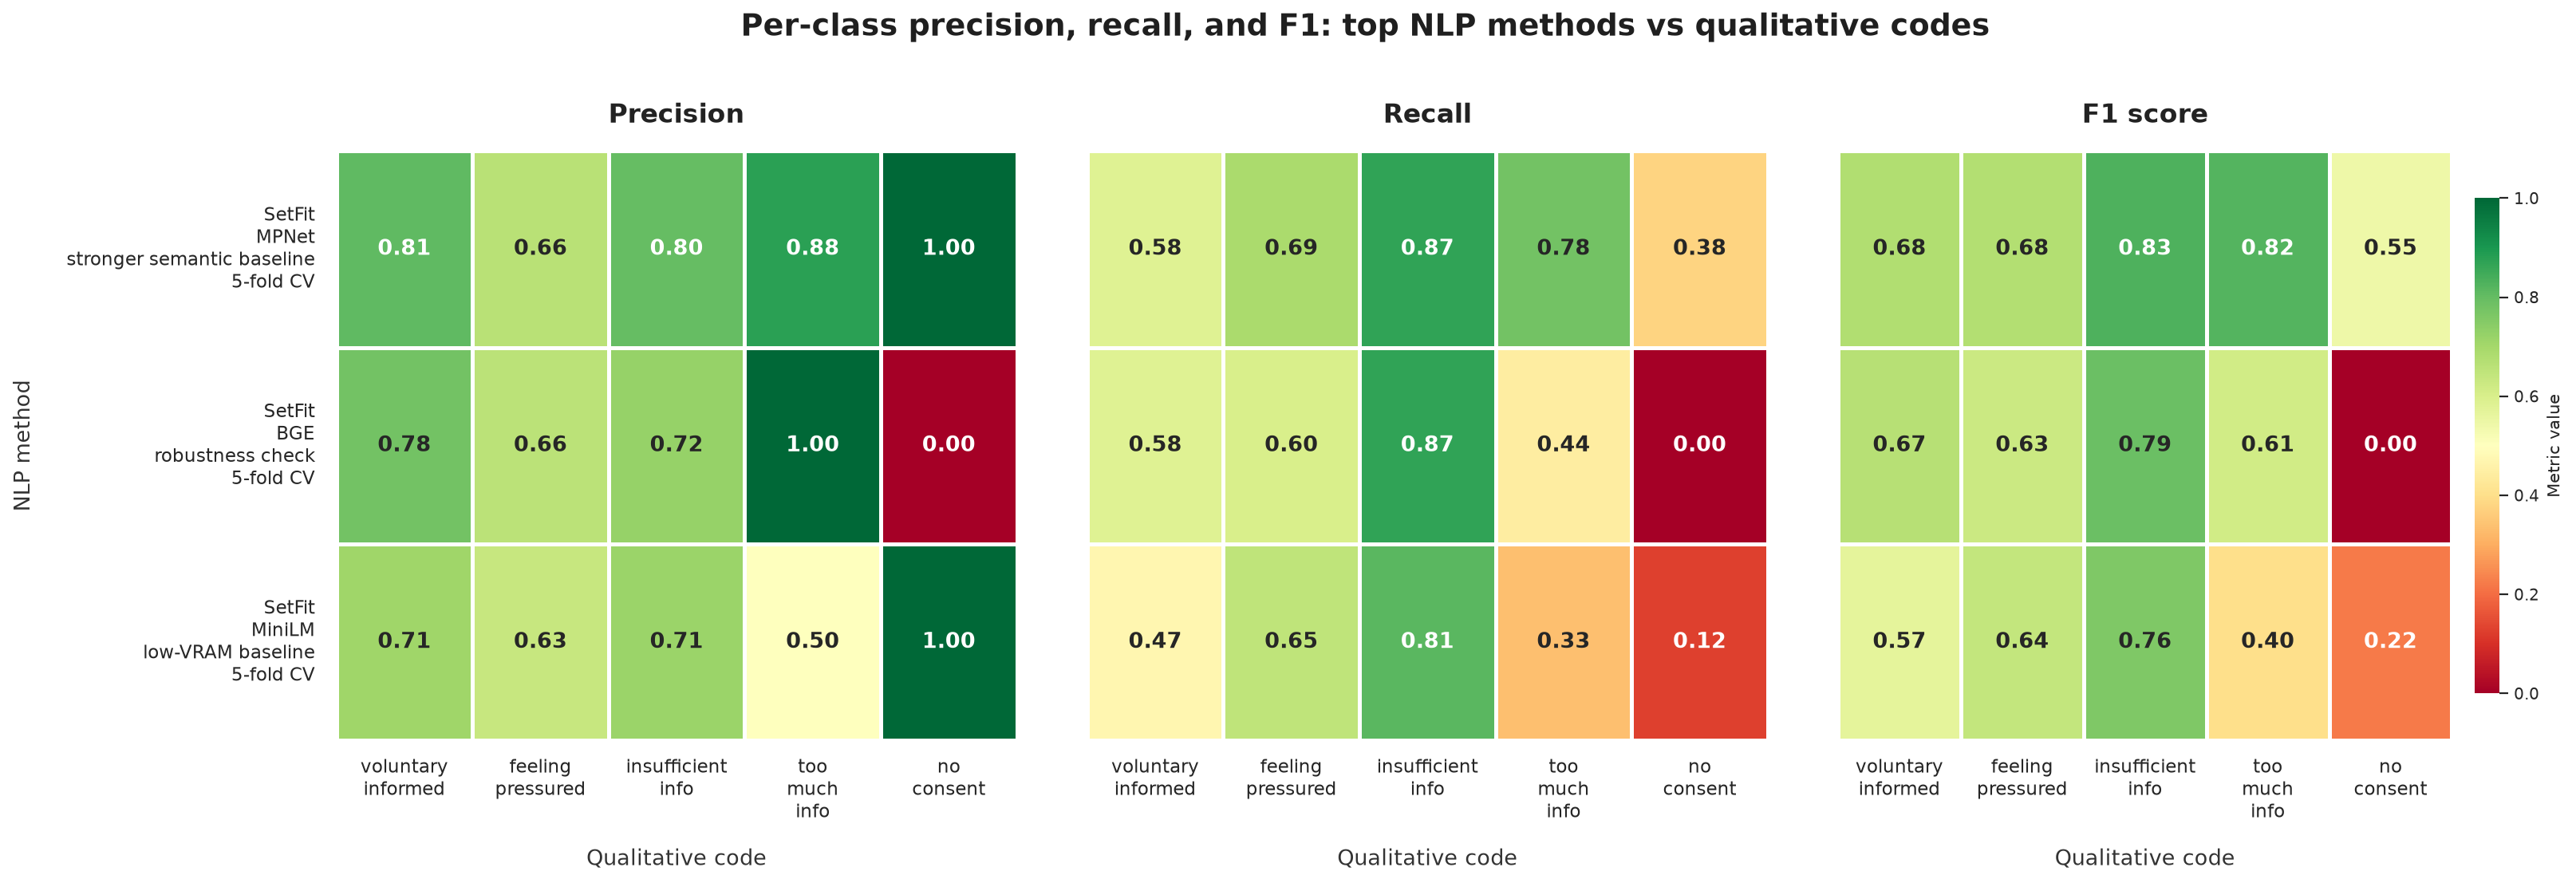

Saved: fig2_per_class_metrics.pdf + .png


,Code,Precision,Recall,F1,Support
0,voluntary_informed,0.808,0.583,0.677,36
1,feeling_pressured,0.663,0.688,0.675,80
2,insufficient_info,0.797,0.869,0.832,145
3,too_much_info,0.875,0.778,0.824,9
4,no_consent,1.000,0.375,0.545,8


Saved: best_method_per_class_metrics.csv

Thesis observation:
  no_consent and too_much_info have very small support (n=8 and n=9).
  Interpret their precision/recall/F1 with uncertainty; rare, context-dependent codes are the least stable.


In [4]:
# Figure 2: Per-class precision / recall / F1 heatmaps
# Show per-class breakdown for top 3 methods, with a thesis-ready spacious layout.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

summary = pd.read_csv(SOURCE_OUTPUT_DIR / 'classification_summary_table.csv')
per_class = pd.read_csv(SOURCE_OUTPUT_DIR / 'classification_per_class_metrics.csv')

CODE_NAMES = ['voluntary_informed', 'feeling_pressured', 'insufficient_info', 'too_much_info', 'no_consent']
top3_methods = summary.head(3)['Method'].tolist()

metric_frames = []
for metric in ['Precision', 'Recall', 'F1']:
    metric_frame = (
        per_class[per_class['Method'].isin(top3_methods)]
        .pivot(index='Method', columns='Code', values=metric)
        .reindex(index=top3_methods, columns=CODE_NAMES)
    )
    metric_frames.append(metric_frame)

code_tick_labels = [code.replace('_', '\n') for code in CODE_NAMES]
method_tick_labels = [
    method.replace('SetFit ', 'SetFit\n')
    .replace(' stronger semantic baseline ', '\nstronger semantic baseline\n')
    .replace(' robustness check ', '\nrobustness check\n')
    .replace(' low-VRAM baseline ', '\nlow-VRAM baseline\n')
    for method in top3_methods
]

sns.set_theme(style='white', context='paper')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'figure.dpi': 160,
    'savefig.dpi': 300,
})

fig, axes = plt.subplots(
    1, 3,
    figsize=(21.5, 7.0),
    sharey=True,
    gridspec_kw={'wspace': 0.10, 'width_ratios': [1, 1, 1.10]}
)

for ax, metric_df, title in zip(axes, metric_frames, ['Precision', 'Recall', 'F1 score']):
    sns.heatmap(
        metric_df,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        linewidths=1.4,
        linecolor='white',
        cbar=ax is axes[-1],
        cbar_kws={'label': 'Metric value', 'shrink': 0.84, 'pad': 0.03},
        annot_kws={'fontsize': 12, 'fontweight': 'bold'},
        ax=ax
    )
    ax.set_title(title, fontsize=15, fontweight='bold', pad=16, color='#222222')
    ax.set_xlabel('Qualitative code', fontsize=12, labelpad=14, color='#333333')
    ax.set_xticklabels(code_tick_labels, rotation=0, ha='center', fontsize=10.5)
    ax.tick_params(axis='x', length=0, pad=9)
    ax.tick_params(axis='y', length=0, pad=12)
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('NLP method', fontsize=12, labelpad=18, color='#333333')
axes[0].set_yticklabels(method_tick_labels, rotation=0, fontsize=10.5, va='center')
for ax in axes[1:]:
    ax.tick_params(axis='y', labelleft=False)

fig.suptitle(
    'Per-class precision, recall, and F1: top NLP methods vs qualitative codes',
    fontsize=17,
    fontweight='bold',
    y=0.985,
    color='#1f1f1f'
)
fig.subplots_adjust(left=0.125, right=0.945, top=0.83, bottom=0.17)

plt.savefig(OUTPUT_DIR / 'fig2_per_class_metrics.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig2_per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig2_per_class_metrics.pdf + .png')

best_method = summary.iloc[0]['Method']
best_per_class_df = (
    per_class[per_class['Method'].eq(best_method)]
    .set_index('Code')
    .reindex(CODE_NAMES)
    .reset_index()[['Code', 'Precision', 'Recall', 'F1', 'Support']]
)
best_per_class_df[['Precision', 'Recall', 'F1']] = best_per_class_df[['Precision', 'Recall', 'F1']].round(3)
best_per_class_df['Support'] = best_per_class_df['Support'].astype(int)
best_per_class_df.to_csv(OUTPUT_DIR / 'best_method_per_class_metrics.csv', index=False)
display(best_per_class_df)
print('Saved: best_method_per_class_metrics.csv')

print('\nThesis observation:')
print('  no_consent and too_much_info have very small support (n=8 and n=9).')
print('  Interpret their precision/recall/F1 with uncertainty; rare, context-dependent codes are the least stable.')


In [5]:
# ── Figure 3: Like-for-like domain phrase / SHAP phrase convergence table ────
# Fair comparison rule: both sides use the same broad Notebook 03_0 2-4 gram vocabulary.
# Broad domain candidates come from Notebook 03_0. The revised Notebook 03 aggregates
# SHAP token attributions only over that same vocabulary used by phrase-aware LIME.
phrase_top = {}
if HAS_DOMAIN_PHRASES:
    for code in CODE_NAMES:
        subset = domain_phrase_map[domain_phrase_map['code_name'] == code].sort_values('evidence_score', ascending=False)
        phrase_top[code] = subset['phrase'].astype(str).str.lower().head(8).tolist()
else:
    phrase_top = {code: [] for code in CODE_NAMES}

shap_phrase_top = {}
shap_phrase_available = HAS_INTERP and 'phrase_shap_by_class' in interp_results
if shap_phrase_available:
    phrase_shap_by_class = interp_results.get('phrase_shap_by_class', {})
    for code in CODE_NAMES:
        if code in phrase_shap_by_class:
            ranked = sorted(phrase_shap_by_class[code].items(), key=lambda x: np.mean(x[1]), reverse=True)
            shap_phrase_top[code] = [str(phrase).lower().replace('_', ' ') for phrase, _ in ranked[:8]]
        else:
            shap_phrase_top[code] = []
else:
    shap_phrase_top = {code: [] for code in CODE_NAMES}
    print('Aligned SHAP phrases not found in the revised interpretability results.')
    print('Re-run Notebook 03 after the phrase-level SHAP update before interpreting this convergence table.')

print('\n══ Method convergence: extracted domain phrases vs aligned SHAP 2-4 gram phrases ══\n')
conv_rows = []
for code in CODE_NAMES:
    p = set(phrase_top.get(code, []))
    s = set(shap_phrase_top.get(code, []))
    overlap = p & s
    conv_rows.append({
        'Code': code,
        'Domain phrases from 03_0': ', '.join(phrase_top.get(code, [])[:6]) or '—',
        'SHAP phrases from 03': ', '.join(shap_phrase_top.get(code, [])[:6]) or '—',
        'Overlap': ', '.join(sorted(overlap)) or '—',
        'n_overlap': len(overlap),
        'comparison_policy': 'both sides restricted to the same broad Notebook 03_0 2-4 gram candidate vocabulary',
    })
    print(f'  [{code}]')
    print(f'    Domain phrases : {phrase_top.get(code, [])[:6]}')
    print(f'    SHAP phrases   : {shap_phrase_top.get(code, [])[:6]}')
    print(f'    overlap        : {sorted(overlap) if overlap else "(none among full-corpus aggregate top phrases)"}\n')

conv_df = pd.DataFrame(conv_rows)
conv_df.to_csv(OUTPUT_DIR / 'method_convergence.csv', index=False)
display(conv_df)



══ Method convergence: extracted domain phrases vs aligned SHAP 2-4 gram phrases ══

  [voluntary_informed]
    Domain phrases : ['was happy', 'my decision', 'labour starting', 'never felt', 'sign of labour', 'go into labour naturally']
    SHAP phrases   : ['was happy to go', 'happy to go', 'was happy', 'was very pleased', 'very pleased', 'very informed']
    overlap        : ['was happy']

  [feeling_pressured]
    Domain phrases : ['felt like', 'felt pressured', 'it felt', "didn't want", 'it felt like', 'want an induction']
    SHAP phrases   : ['forced on women', 'pressured to accept', 'under pressure', 'wanted to avoid', 'can refuse', 'scare mongered']
    overlap        : (none among full-corpus aggregate top phrases)

  [insufficient_info]
    Domain phrases : ['was not', 'more information', 'not informed', 'information given', 'enough information', 'risks of induction']
    SHAP phrases   : ['forced on women', 'under pressure', 'not informed enough', 'not know', 'was happy to 

,Code,Domain phrases from 03_0,SHAP phrases from 03,Overlap,n_overlap,comparison_policy
0,voluntary_informed,"was happy, my decision, labour starting, never...","was happy to go, happy to go, was happy, was v...",was happy,1,both sides restricted to the same broad Notebo...
1,feeling_pressured,"felt like, felt pressured, it felt, didn't wan...","forced on women, pressured to accept, under pr...",—,0,both sides restricted to the same broad Notebo...
2,insufficient_info,"was not, more information, not informed, infor...","forced on women, under pressure, not informed ...",—,0,both sides restricted to the same broad Notebo...
3,too_much_info,"negative stories, positive stories, about indu...","negative stories, positive stories, positive e...","negative stories, positive stories",2,both sides restricted to the same broad Notebo...
4,no_consent,"vaginal exam, no consent, if wanted, my water,...","no consent, my consent, without my consent, no...","no consent, without my consent",2,both sides restricted to the same broad Notebo...


##  full-corpus phrase-aware SHAP-LIME agreement
now explains all 278 decision-making responses. Agreement is reported overall and stratified by final human code and Notebook 02 out-of-fold correctness; the analysis is no longer a 20-case interpretability subset.


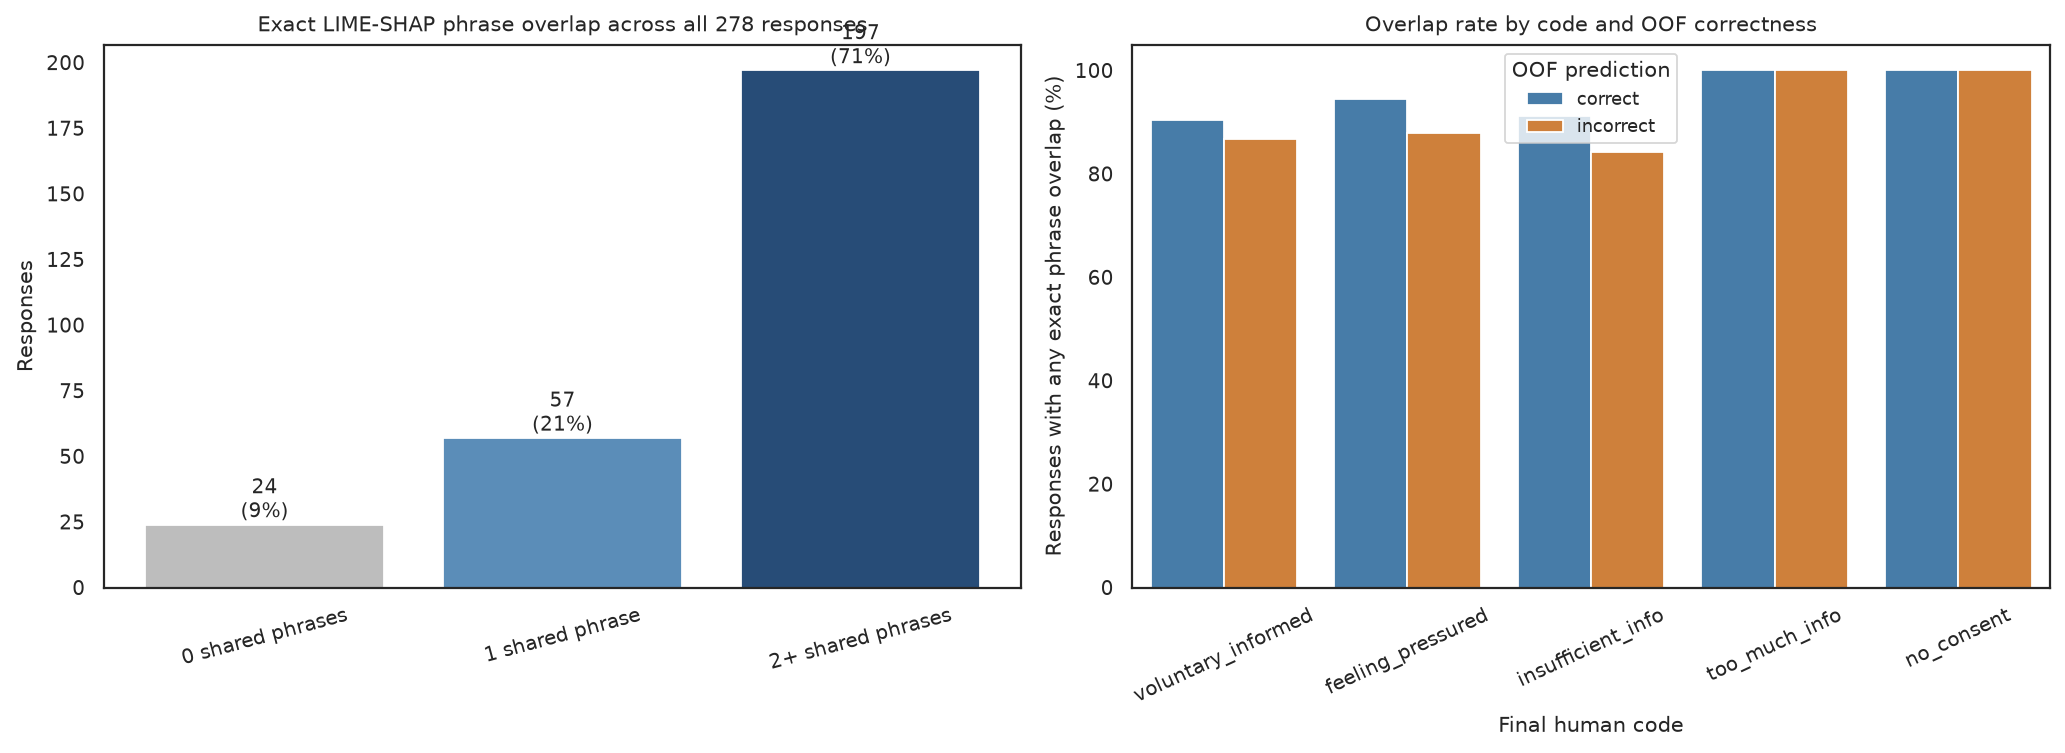

Full-corpus coverage: 278/278 responses
Exact-overlap responses: 254/278 (91.4%)
Median exact shared phrases per response: 2
Finite Spearman correlations: 135/278
Interpretation: low exact overlap is a full-corpus explainer-stability finding; it does not show which explainer is correct and does not prove that automation is impossible.


,true_code,prediction_status,n_responses,responses_with_exact_overlap,median_shared_phrases,mean_exact_jaccard,median_exact_jaccard,estimable_spearman,mean_spearman,exact_overlap_rate
0,feeling_pressured,correct,55,52,3.0,0.522261,0.500000,33,0.505411,0.945455
1,feeling_pressured,incorrect,25,22,2.0,0.527464,0.500000,11,0.272727,0.880000
2,insufficient_info,correct,126,115,2.0,0.563898,0.500000,57,0.428906,0.912698
3,insufficient_info,incorrect,19,16,2.0,0.577330,0.550000,9,0.300000,0.842105
4,no_consent,correct,3,3,2.0,0.618056,0.666667,1,1.000000,1.000000
5,no_consent,incorrect,5,5,5.0,0.606190,0.583333,4,0.189286,1.000000
6,too_much_info,correct,7,7,2.0,0.781746,0.750000,2,0.578571,1.000000
7,too_much_info,incorrect,2,2,4.5,0.928571,0.928571,2,0.492857,1.000000
8,voluntary_informed,correct,21,19,2.0,0.602208,0.558442,9,0.865079,0.904762
9,voluntary_informed,incorrect,15,13,2.0,0.542827,0.500000,7,0.066667,0.866667


In [6]:
if HAS_INTERP and 'agreement_df' in interp_results:
    agreement_df = interp_results['agreement_df'].copy()
    agreement_df['exact_jaccard_topk'] = pd.to_numeric(agreement_df.get('exact_jaccard_topk'), errors='coerce')
    agreement_df['n_common'] = pd.to_numeric(agreement_df['n_common'], errors='coerce').fillna(0).astype(int)
    agreement_df['prediction_status'] = np.where(agreement_df['oof_error'], 'incorrect', 'correct')

    stratified = interp_results.get('agreement_stratified_df', pd.DataFrame()).copy()
    if stratified.empty:
        stratified = (
            agreement_df.groupby(['true_code', 'prediction_status'])
            .agg(
                n_responses=('doc_idx', 'size'),
                responses_with_exact_overlap=('n_common', lambda s: int((s > 0).sum())),
                median_shared_phrases=('n_common', 'median'),
                mean_exact_jaccard=('exact_jaccard_topk', 'mean'),
            )
            .reset_index()
        )
        stratified['exact_overlap_rate'] = stratified['responses_with_exact_overlap'] / stratified['n_responses']

    overlap_counts = (
        agreement_df.assign(overlap_group=np.select(
            [agreement_df['n_common'].eq(0), agreement_df['n_common'].eq(1)],
            ['0 shared phrases', '1 shared phrase'],
            default='2+ shared phrases',
        ))
        .groupby('overlap_group').size()
        .reindex(['0 shared phrases', '1 shared phrase', '2+ shared phrases'], fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    axes[0].bar(overlap_counts.index, overlap_counts.values, color=['#bdbdbd', '#5b8db8', '#274c77'])
    axes[0].set_ylabel('Responses')
    axes[0].set_title(f'Exact LIME-SHAP phrase overlap across all {len(agreement_df)} responses')
    axes[0].tick_params(axis='x', rotation=15)
    for i, value in enumerate(overlap_counts.values):
        axes[0].text(i, value + max(1, len(agreement_df) * 0.01), f'{value}\n({value/len(agreement_df):.0%})', ha='center', fontsize=9)

    plot_df = stratified.copy()
    plot_df['exact_overlap_pct'] = pd.to_numeric(plot_df['exact_overlap_rate'], errors='coerce') * 100
    sns.barplot(
        data=plot_df,
        x='true_code', y='exact_overlap_pct', hue='prediction_status',
        order=CODE_NAMES, hue_order=['correct', 'incorrect'],
        errorbar=None, palette={'correct': '#377eb8', 'incorrect': '#e67e22'}, ax=axes[1],
    )
    axes[1].set_xlabel('Final human code')
    axes[1].set_ylabel('Responses with any exact phrase overlap (%)')
    axes[1].set_title('Overlap rate by code and OOF correctness')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].legend(title='OOF prediction', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig3_shap_lime_agreement.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'fig3_shap_lime_agreement.png', dpi=200, bbox_inches='tight')
    plt.show()

    review_summary = (
        agreement_df.groupby('true_code')
        .agg(
            total_responses=('doc_idx', 'size'),
            exact_overlap_responses=('n_common', lambda s: int((s > 0).sum())),
            median_shared_phrases=('n_common', 'median'),
            mean_exact_jaccard=('exact_jaccard_topk', 'mean'),
        )
        .reindex(CODE_NAMES)
    )
    review_summary['exact_overlap_rate'] = review_summary['exact_overlap_responses'] / review_summary['total_responses']
    review_summary.to_csv(OUTPUT_DIR / 'interpretability_review_summary.csv')
    stratified.to_csv(OUTPUT_DIR / 'shap_lime_agreement_stratified.csv', index=False)

    finite_rho = pd.to_numeric(agreement_df.get('spearman_rho'), errors='coerce').notna().sum()
    any_overlap = int((agreement_df['n_common'] > 0).sum())
    print(f'Full-corpus coverage: {len(agreement_df)}/278 responses')
    print(f'Exact-overlap responses: {any_overlap}/{len(agreement_df)} ({any_overlap/len(agreement_df):.1%})')
    print(f'Median exact shared phrases per response: {agreement_df["n_common"].median():.0f}')
    print(f'Finite Spearman correlations: {finite_rho}/{len(agreement_df)}')
    print('Interpretation: low exact overlap is a full-corpus explainer-stability finding; it does not show which explainer is correct and does not prove that automation is impossible.')
    display(stratified)
else:
    print('Run Notebook 03 first to generate the full-corpus interpretability summary.')


## 4. Triangulated phrase evidence: human code + LIME + SHAP

This section combines Notebook 03_1's human-label phrase associations with full-corpus LIME and SHAP attributions. A phrase is counted as three-way evidence only when the same or near-matched phrase is present in all three sources for a response. Partial agreement remains descriptive evidence, while full convergence is deliberately conservative and is not treated as causal validation.


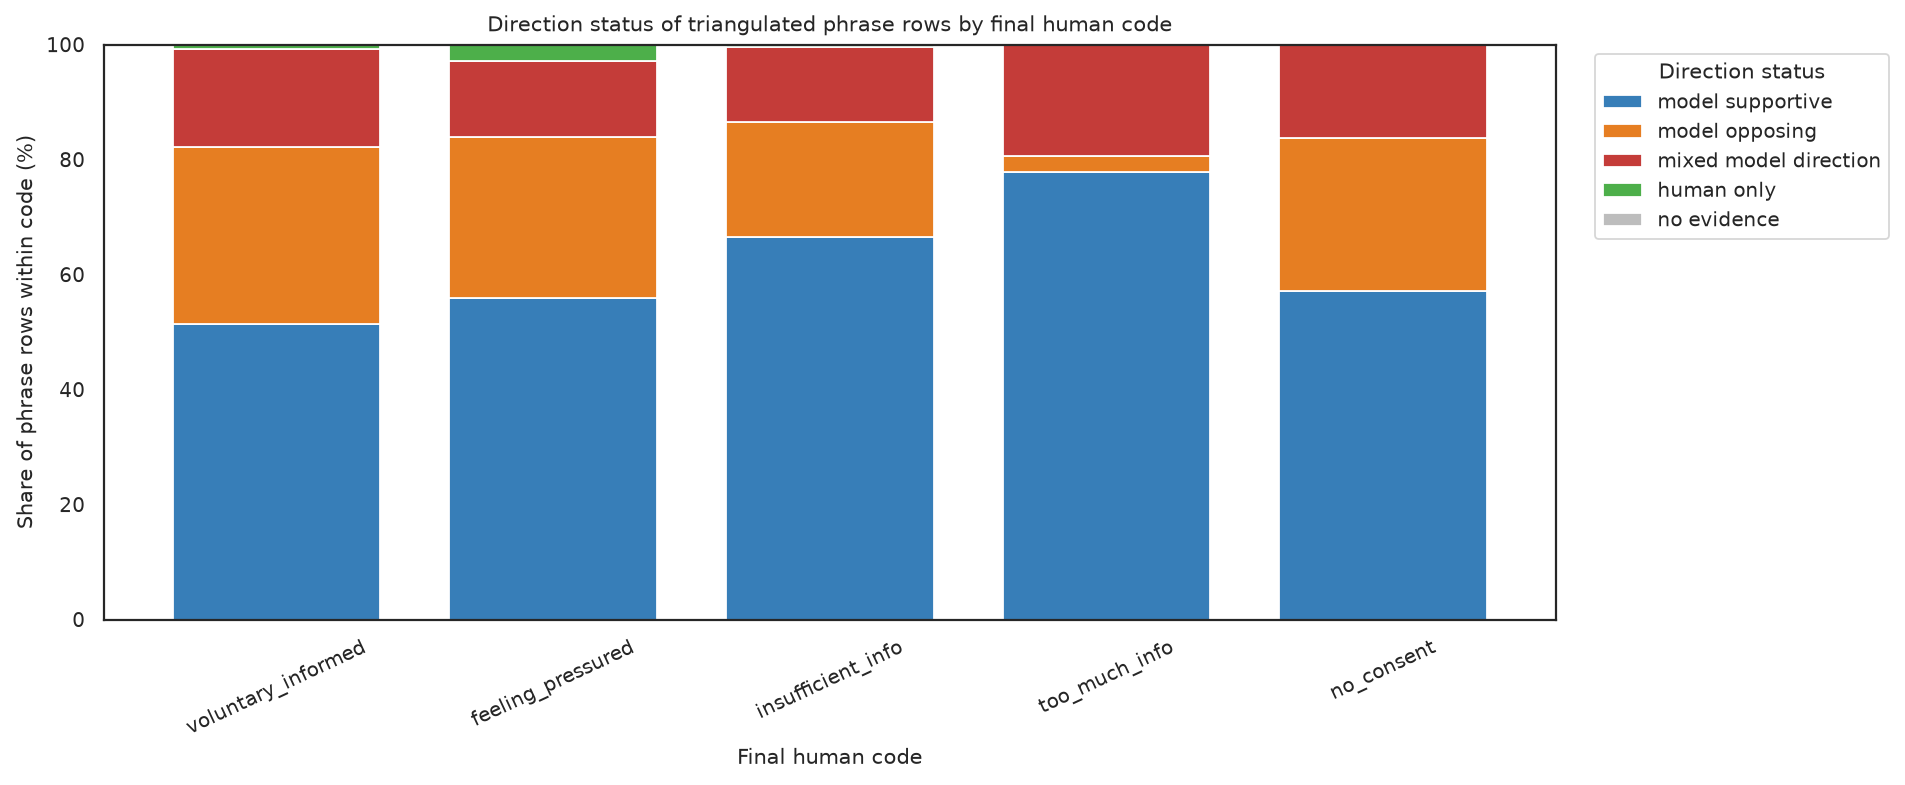

Triangulated phrase rows: 1305
Responses with at least one triangulatable broad candidate phrase: 265/278
Responses with at least one three-way human_code+LIME+SHAP phrase: 208/278
Responses with at least one human_code+SHAP phrase: 103/278
The figure reports phrase-row composition within each code, not response prevalence.


source_pattern,Code,human_code+lime+shap,human_code+lime,human_code+shap,lime+shap,human_code,lime,shap
0,voluntary_informed,35,1,10,61,1,6,26
1,feeling_pressured,126,10,107,103,12,5,61
2,insufficient_info,270,22,98,143,3,12,108
3,too_much_info,14,0,2,15,0,1,4
4,no_consent,4,0,4,25,0,1,15



Strongest three-way or partial evidence rows:


,doc_idx,true_code,setfit_cv_pred,canonical_phrase,source_pattern,p_code_given_phrase,lift,directional_source_pattern,evidence_direction_status,triangulation_score
0,271,no_consent,no_consent,vaginal exam,human_code+lime+shap,1.000000,34.750000,human_code+lime_positive+shap_positive,model supportive,1.0
1,264,too_much_info,too_much_info,negative stories,human_code+lime+shap,1.000000,30.888889,human_code+lime_positive+shap_positive,model supportive,1.0
2,266,too_much_info,too_much_info,positive stories,human_code+lime+shap,1.000000,30.888889,human_code+lime_positive+shap_positive,model supportive,1.0
3,11,voluntary_informed,voluntary_informed,my decision,human_code+lime+shap,1.000000,7.722222,human_code+lime_positive+shap_positive,model supportive,1.0
4,3,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,0.750000,5.791667,human_code+lime_positive+shap_positive,model supportive,1.0
5,5,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,0.750000,5.791667,human_code+lime_positive+shap_positive,model supportive,1.0
6,26,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,0.750000,5.791667,human_code+lime_positive+shap_positive,model supportive,1.0
7,31,voluntary_informed,voluntary_informed,was happy,human_code+lime+shap,0.750000,5.791667,human_code+lime_positive+shap_positive,model supportive,1.0
8,34,voluntary_informed,feeling_pressured,was happy,human_code+lime+shap,0.750000,5.791667,human_code+lime_positive+shap_positive,model supportive,1.0
9,273,no_consent,no_consent,no consent,human_code+lime+shap,0.666667,23.166667,human_code+lime_positive+shap_positive,model supportive,1.0


Saved: fig_triangulation_pattern_summary.pdf + .png
Saved: triangulation_pattern_summary.csv, triangulation_pattern_wide.csv, triangulated_phrase_evidence.csv


In [7]:
if HAS_TRIANGULATION:
    triangulation_pattern_summary.to_csv(OUTPUT_DIR / 'triangulation_pattern_summary.csv', index=False)
    triangulated_phrase_evidence_df.to_csv(OUTPUT_DIR / 'triangulated_phrase_evidence.csv', index=False)
    triangulated_top_by_response_df.to_csv(OUTPUT_DIR / 'triangulated_phrase_evidence_top_by_response.csv', index=False)

    direction_order = ['model supportive', 'model opposing', 'mixed model direction', 'human only', 'no evidence']
    direction_wide = (
        triangulation_pattern_summary
        .pivot_table(index='true_code', columns='evidence_direction_status', values='phrase_rows', aggfunc='sum', fill_value=0)
        .reindex(CODE_NAMES, fill_value=0)
        .reindex(columns=direction_order, fill_value=0)
    )
    direction_pct = direction_wide.div(direction_wide.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
    colors = ['#377eb8', '#e67e22', '#c43c39', '#4daf4a', '#bdbdbd']
    ax = direction_pct.plot(kind='bar', stacked=True, figsize=(12, 5), color=colors, width=0.75)
    ax.set_title('Direction status of triangulated phrase rows by final human code')
    ax.set_xlabel('Final human code')
    ax.set_ylabel('Share of phrase rows within code (%)')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Direction status', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_triangulation_pattern_summary.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'fig_triangulation_pattern_summary.png', dpi=200, bbox_inches='tight')
    plt.show()

    source_order = ['human_code+lime+shap', 'human_code+lime', 'human_code+shap', 'lime+shap', 'human_code', 'lime', 'shap']
    pattern_wide = (
        triangulation_pattern_summary
        .pivot_table(index='true_code', columns='source_pattern', values='phrase_rows', aggfunc='sum', fill_value=0)
        .reindex(CODE_NAMES, fill_value=0)
        .reindex(columns=source_order, fill_value=0)
    )
    pattern_wide.to_csv(OUTPUT_DIR / 'triangulation_pattern_wide.csv')

    represented_responses = int(triangulated_phrase_evidence_df['doc_idx'].nunique())
    triple_rows = triangulated_phrase_evidence_df['source_pattern'].eq('human_code+lime+shap')
    triple_response_count = int(triangulated_phrase_evidence_df.loc[triple_rows, 'doc_idx'].nunique())
    human_shap_response_count = int(triangulated_phrase_evidence_df.loc[
        triangulated_phrase_evidence_df['source_pattern'].eq('human_code+shap'), 'doc_idx'
    ].nunique())

    print(f'Triangulated phrase rows: {len(triangulated_phrase_evidence_df)}')
    print(f'Responses with at least one triangulatable broad candidate phrase: {represented_responses}/278')
    print(f'Responses with at least one three-way human_code+LIME+SHAP phrase: {triple_response_count}/278')
    print(f'Responses with at least one human_code+SHAP phrase: {human_shap_response_count}/278')
    print('The figure reports phrase-row composition within each code, not response prevalence.')
    display(pattern_wide.reset_index().rename(columns={'true_code': 'Code'}))

    print('\nStrongest three-way or partial evidence rows:')
    display_cols = [
        'doc_idx', 'true_code', 'setfit_cv_pred', 'canonical_phrase', 'source_pattern',
        'p_code_given_phrase', 'lift', 'directional_source_pattern', 'evidence_direction_status', 'triangulation_score'
    ]
    display(
        triangulated_phrase_evidence_df[
            triangulated_phrase_evidence_df['source_pattern'].isin(['human_code+lime+shap', 'human_code+lime', 'human_code+shap'])
        ][display_cols].head(20)
    )
    print('Saved: fig_triangulation_pattern_summary.pdf + .png')
    print('Saved: triangulation_pattern_summary.csv, triangulation_pattern_wide.csv, triangulated_phrase_evidence.csv')
else:
    print('Run Notebook 03_1 and rerun Notebook 03 to generate full-corpus triangulated phrase evidence.')


In [8]:
# ── Maximum-effect constituent words within explained phrases ───────────────
# LIME encoded retained multi-word phrases as single perturbation units, so it
# provides a phrase-level coefficient but cannot identify a constituent word.
# SHAP retains ordered token/chunk values. When a SHAP chunk contains multiple
# words, its value is divided equally across those words, matching Notebook 03's
# phrase aggregation policy. Only phrases with a matched SHAP span are included.

def _canonical_shap_words(token):
    token = str(token).lower().replace('Ġ', ' ')
    token = re.sub(r"[^a-z0-9'\s_]+", ' ', token.replace('_', ' '))
    return [word for word in re.sub(r'\s+', ' ', token).strip().split() if word]


def _shap_word_stream(shap_item, class_idx):
    words, word_values = [], []
    class_values = np.asarray(shap_item['values'])[:, class_idx]
    for token, token_value in zip(shap_item['data'], class_values):
        token_words = _canonical_shap_words(token)
        if not token_words:
            continue
        allocated_value = float(token_value) / len(token_words)
        words.extend(token_words)
        word_values.extend([allocated_value] * len(token_words))
    return words, np.asarray(word_values, dtype=float)


def _matched_phrase_positions(words, phrase_words):
    phrase_len = len(phrase_words)
    return [
        start for start in range(len(words) - phrase_len + 1)
        if words[start:start + phrase_len] == phrase_words
    ]


MAX_WORD_DETAIL_PATH = OUTPUT_DIR / 'phrase_max_effect_word_samples.csv'
MAX_WORD_SUMMARY_PATH = OUTPUT_DIR / 'phrase_max_effect_word_summary.csv'

max_effect_word_rows = []
if HAS_INTERP and HAS_TRIANGULATION and 'shap_values_serializable' in interp_results:
    phrase_samples = triangulated_top_by_response_df.copy()
    if phrase_samples.empty:
        phrase_samples = triangulated_phrase_evidence_df.copy()

    phrase_samples['shap_supported'] = (
        phrase_samples['shap_supported'].astype(str).str.lower().eq('true')
    )
    measurable_candidates = phrase_samples[
        phrase_samples['shap_supported']
        & phrase_samples['shap_phrase'].fillna('').astype(str).str.strip().ne('')
    ].copy()

    shap_values_by_doc = interp_results['shap_values_serializable']
    for row in measurable_candidates.itertuples(index=False):
        doc_idx = int(row.doc_idx)
        shap_item = shap_values_by_doc.get(doc_idx)
        if shap_item is None:
            continue

        explanation_target = str(row.final_explainer_pred)
        class_idx = int(DECISION_CODES[explanation_target])
        words, word_values = _shap_word_stream(shap_item, class_idx)
        phrase = ' '.join(_canonical_shap_words(row.shap_phrase))
        phrase_words = phrase.split()
        positions = _matched_phrase_positions(words, phrase_words)
        if not positions:
            continue

        matched_words = []
        matched_values = []
        for start in positions:
            end = start + len(phrase_words)
            matched_words.extend(words[start:end])
            matched_values.extend(word_values[start:end].tolist())

        strongest_idx = int(np.argmax(np.abs(matched_values)))
        strongest_word = matched_words[strongest_idx]
        strongest_value = float(matched_values[strongest_idx])
        total_matched_abs = float(np.abs(matched_values).sum())
        lime_raw = pd.to_numeric(pd.Series([getattr(row, 'lime_raw', np.nan)]), errors='coerce').iloc[0]
        shap_phrase_raw = pd.to_numeric(pd.Series([getattr(row, 'shap_raw', np.nan)]), errors='coerce').iloc[0]

        max_effect_word_rows.append({
            'doc_idx': doc_idx,
            'response_id': row.response_id,
            'true_code': row.true_code,
            'explanation_target': explanation_target,
            'canonical_phrase': row.canonical_phrase,
            'shap_phrase': phrase,
            'shap_max_effect_word': strongest_word,
            'shap_max_word_raw': strongest_value,
            'shap_max_word_abs': abs(strongest_value),
            'shap_max_word_direction': 'supports' if strongest_value > 0 else ('opposes' if strongest_value < 0 else 'neutral'),
            'shap_phrase_raw_reported': shap_phrase_raw,
            'shap_phrase_occurrences': len(positions),
            'shap_max_word_share_of_matched_abs': abs(strongest_value) / total_matched_abs if total_matched_abs else np.nan,
            'lime_phrase': getattr(row, 'lime_phrase', ''),
            'lime_phrase_raw': lime_raw,
            'lime_phrase_score_available': bool(pd.notna(lime_raw)),
            'lime_constituent_word_measurable': False,
            'measurement_scope': 'SHAP constituent word; LIME phrase-level only',
            'response_text': row.response_text,
        })

phrase_max_effect_word_samples = pd.DataFrame(max_effect_word_rows)
if not phrase_max_effect_word_samples.empty:
    phrase_max_effect_word_samples = phrase_max_effect_word_samples.sort_values(
        ['shap_max_word_abs', 'doc_idx'], ascending=[False, True]
    ).reset_index(drop=True)
    phrase_max_effect_word_samples.to_csv(MAX_WORD_DETAIL_PATH, index=False)

    phrase_max_effect_word_summary = (
        phrase_max_effect_word_samples
        .groupby(
            ['true_code', 'explanation_target', 'canonical_phrase', 'shap_max_effect_word', 'shap_max_word_direction'],
            dropna=False,
        )
        .agg(
            response_phrase_samples=('doc_idx', 'size'),
            unique_responses=('doc_idx', 'nunique'),
            mean_abs_shap_word_effect=('shap_max_word_abs', 'mean'),
            max_abs_shap_word_effect=('shap_max_word_abs', 'max'),
            mean_shap_word_share_of_phrase_abs=('shap_max_word_share_of_matched_abs', 'mean'),
            lime_phrase_scores_available=('lime_phrase_score_available', 'sum'),
            example_doc_idx=('doc_idx', 'first'),
            example_response=('response_text', 'first'),
        )
        .reset_index()
        .sort_values(
            ['response_phrase_samples', 'mean_abs_shap_word_effect'],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )
    phrase_max_effect_word_summary.to_csv(MAX_WORD_SUMMARY_PATH, index=False)

    print(f'Measurable SHAP response-phrase samples: {len(phrase_max_effect_word_samples)}')
    print(f'Unique responses represented: {phrase_max_effect_word_samples["doc_idx"].nunique()}/278')
    print(f'Rows also carrying a LIME phrase-level score: {int(phrase_max_effect_word_samples["lime_phrase_score_available"].sum())}')
    print('LIME constituent-word values are unavailable by design because retained phrases were encoded as single LIME features.')
    print('SHAP multi-word chunks use equal value allocation across constituent words, consistent with Notebook 03 phrase aggregation.')
    display(phrase_max_effect_word_summary.head(30))
    print(f'Saved: {MAX_WORD_DETAIL_PATH}')
    print(f'Saved: {MAX_WORD_SUMMARY_PATH}')
else:
    phrase_max_effect_word_summary = pd.DataFrame()
    print('No phrase rows had a matched SHAP span with measurable constituent-word information.')


Measurable SHAP response-phrase samples: 916
Unique responses represented: 264/278
Rows also carrying a LIME phrase-level score: 712
LIME constituent-word values are unavailable by design because retained phrases were encoded as single LIME features.
SHAP multi-word chunks use equal value allocation across constituent words, consistent with Notebook 03 phrase aggregation.


,true_code,explanation_target,canonical_phrase,shap_max_effect_word,shap_max_word_direction,response_phrase_samples,unique_responses,mean_abs_shap_word_effect,max_abs_shap_word_effect,mean_shap_word_share_of_phrase_abs,lime_phrase_scores_available,example_doc_idx,example_response
0,insufficient_info,insufficient_info,was not,not,supports,8,8,0.134282,0.285206,0.819994,8,255,I was not told the chances of it failing / tak...
1,insufficient_info,insufficient_info,more information,information,supports,8,8,0.124930,0.221564,0.860472,8,139,More information and not to keave woman berthi...
2,insufficient_info,insufficient_info,are not,not,supports,7,7,0.052731,0.101441,0.764258,6,171,I think that they are are potentially overused...
3,voluntary_informed,voluntary_informed,was happy,happy,supports,6,6,0.378096,0.603980,0.796049,6,15,I was happy to go with the midwife's suggestions.
4,feeling_pressured,feeling_pressured,was told,told,supports,6,6,0.034956,0.057146,0.549182,5,43,Once I was told I was in active labour my seco...
5,feeling_pressured,feeling_pressured,felt pressured,pressured,supports,5,5,0.143797,0.322888,0.676511,5,82,I felt pressured to agree to an induction at 4...
6,insufficient_info,insufficient_info,information given,information,supports,5,5,0.106827,0.182592,0.795648,5,131,Not enough information given or explained clea...
7,insufficient_info,insufficient_info,not enough,enough,supports,5,5,0.047104,0.096523,0.587704,4,131,Not enough information given or explained clea...
8,insufficient_info,insufficient_info,own research,research,supports,4,4,0.153199,0.233987,0.911059,4,164,I believe from reading chart and from my own r...
9,insufficient_info,insufficient_info,waters broke,broke,supports,4,4,0.088806,0.162880,0.698932,2,150,I was also induced on my first baby- waters br...


Saved: outputs\broad_candidate_revision\evaluation_policy\phrase_max_effect_word_samples.csv
Saved: outputs\broad_candidate_revision\evaluation_policy\phrase_max_effect_word_summary.csv


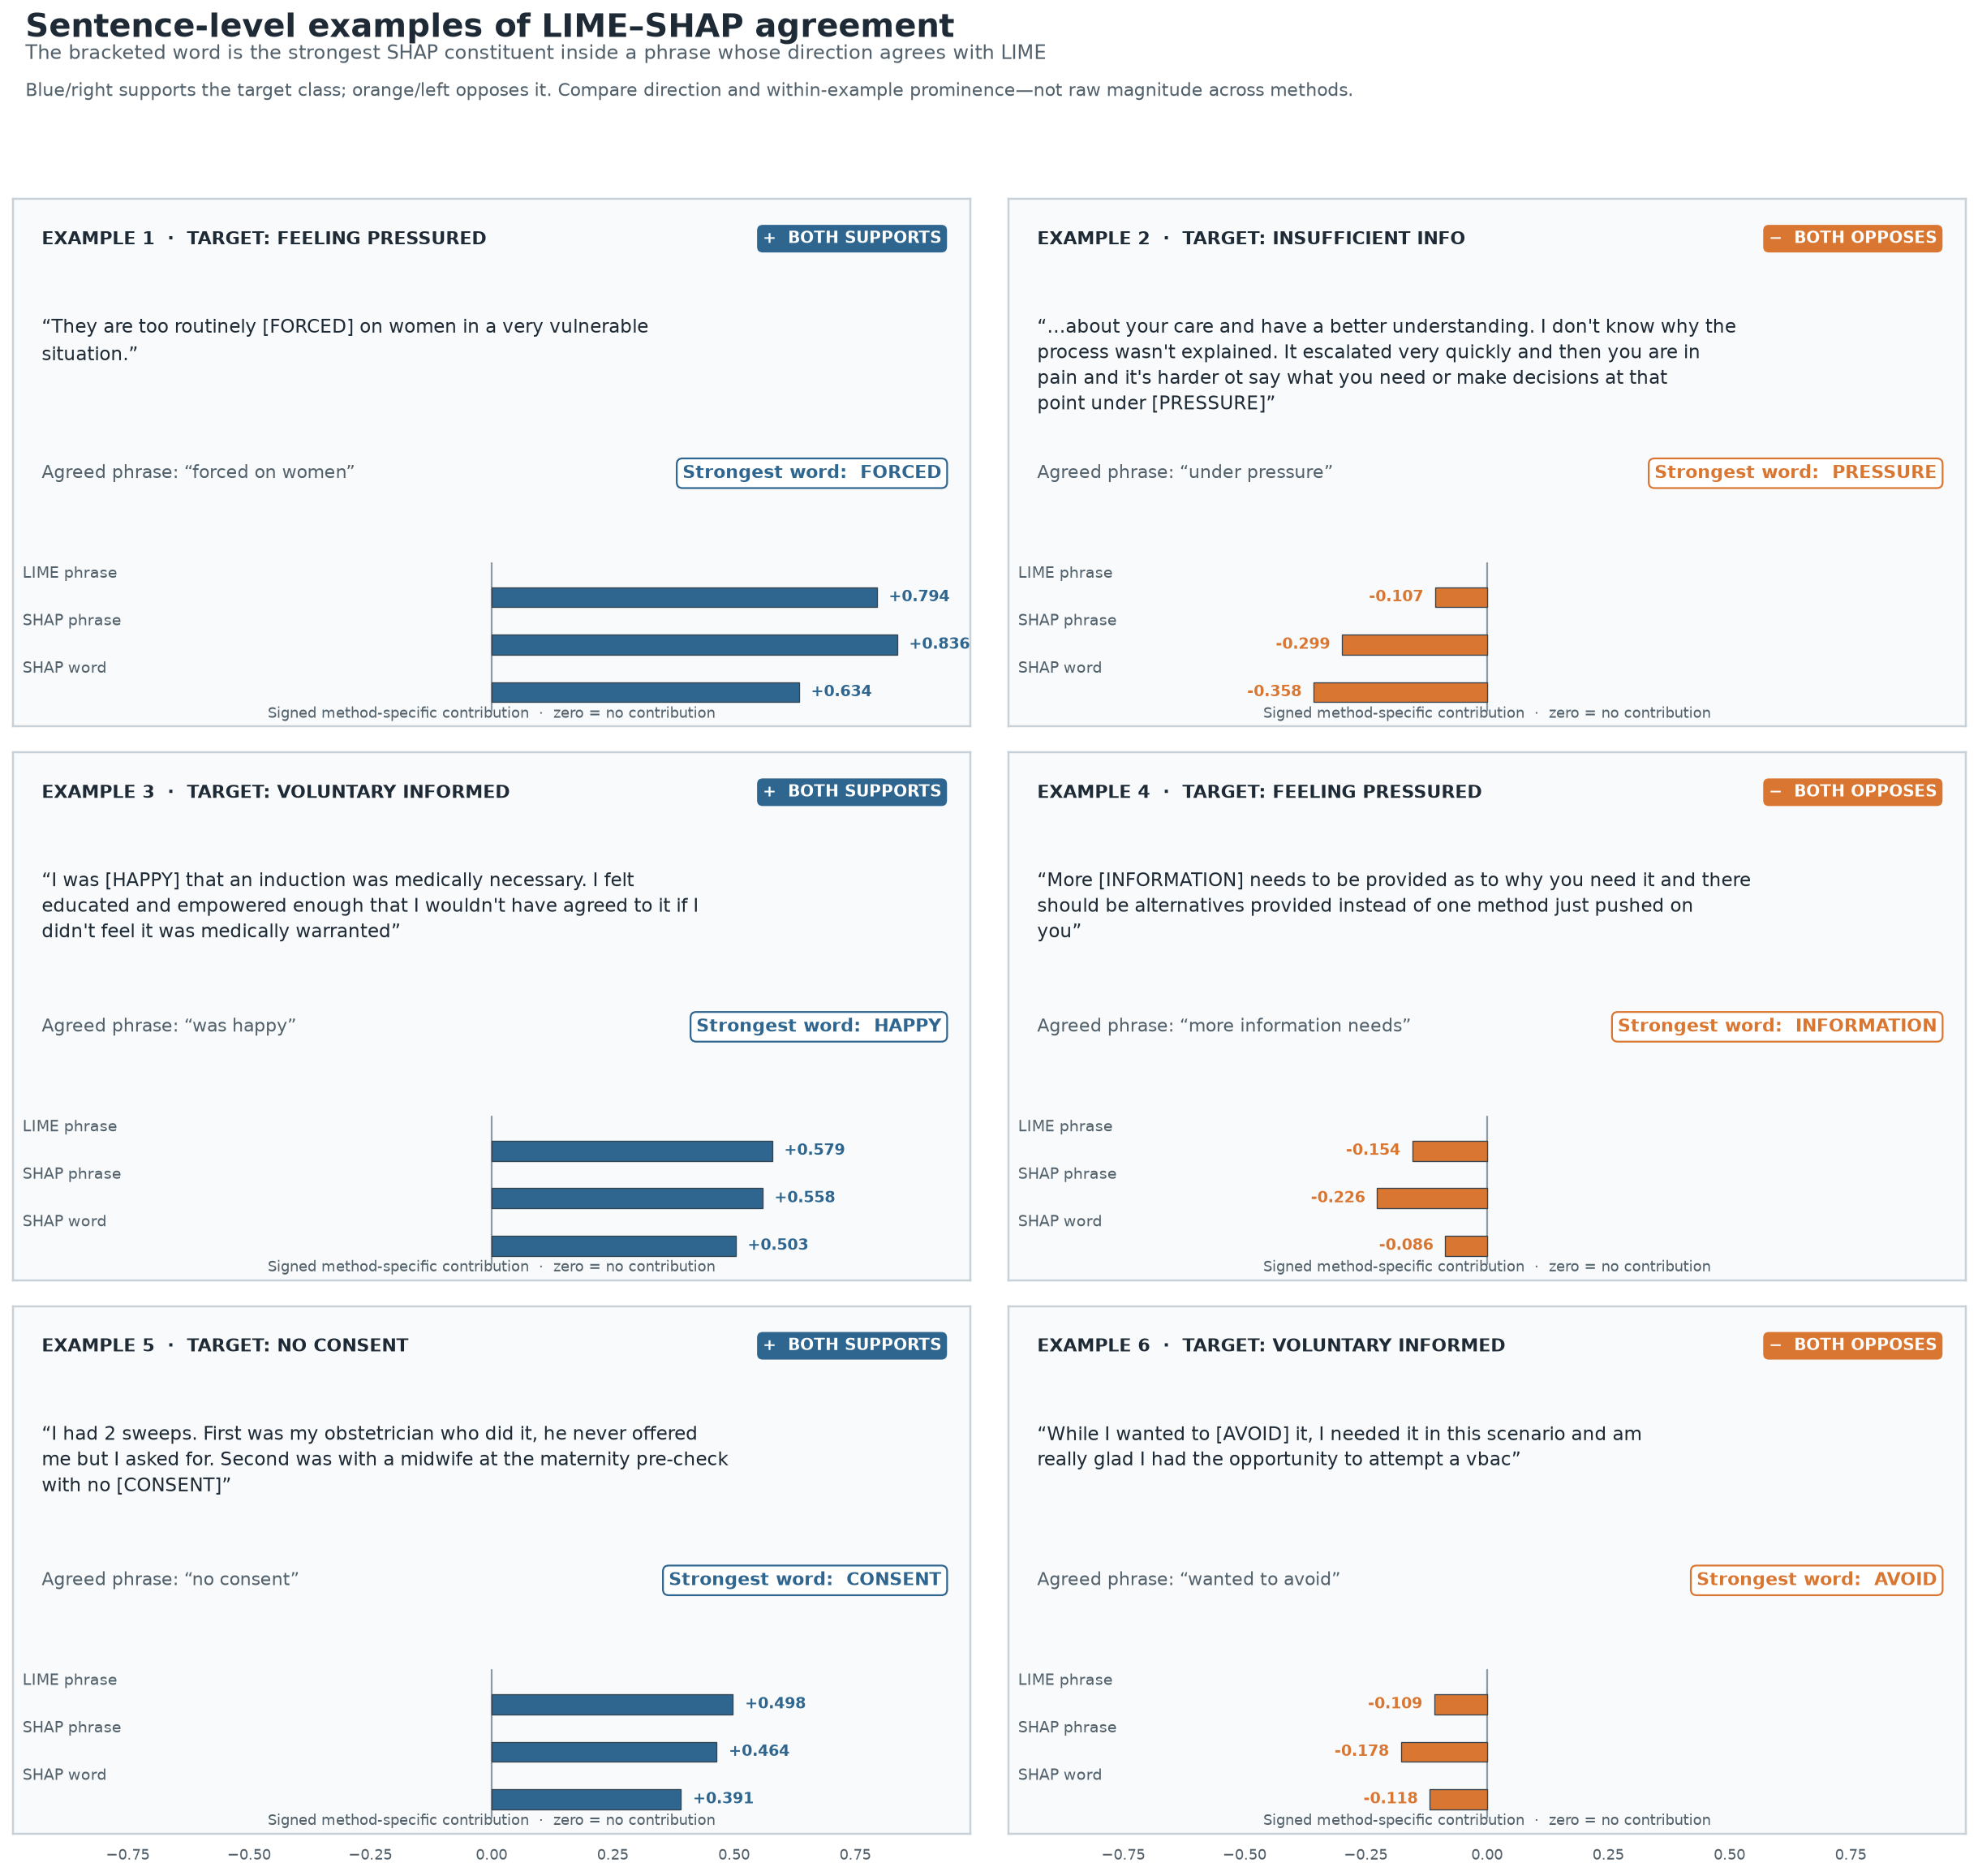

doc_idx,explanation_target,sentence_excerpt,agreed_phrase,maximum_effect_shap_word,lime_phrase_contribution,shap_phrase_contribution,shap_word_contribution,agreement_direction
105,feeling_pressured,They are too routinely [FORCED] on women in a very vulnerable situation.,forced on women,forced,+0.794,+0.836,+0.634,supports
253,insufficient_info,…about your care and have a better understanding. I don't know why the process wasn't explained. It escalated very quickly and then you are in pain and it's harder ot say what you need or make decisions at that point under [PRESSURE],under pressure,pressure,-0.107,-0.299,-0.358,opposes
3,voluntary_informed,I was [HAPPY] that an induction was medically necessary. I felt educated and empowered enough that I wouldn't have agreed to it if I didn't feel it was medically warranted,was happy,happy,+0.579,+0.558,+0.503,supports
110,feeling_pressured,More [INFORMATION] needs to be provided as to why you need it and there should be alternatives provided instead of one method just pushed on you,more information needs,information,-0.154,-0.226,-0.086,opposes
273,no_consent,"I had 2 sweeps. First was my obstetrician who did it, he never offered me but I asked for. Second was with a midwife at the maternity pre-check with no [CONSENT]",no consent,consent,+0.498,+0.464,+0.391,supports
2,voluntary_informed,"While I wanted to [AVOID] it, I needed it in this scenario and am really glad I had the opportunity to attempt a vbac",wanted to avoid,avoid,-0.109,-0.178,-0.118,opposes


Saved: fig_lime_shap_sentence_examples.png + .pdf
Saved: lime_shap_best_sentence_examples.csv


In [9]:
# ── Best sentence-level examples of LIME–SHAP directional agreement ─────────
# Selection rule: exact response/phrase cases with strong within-response ranks,
# the same LIME and SHAP phrase direction, and interpretable contextual contrasts.
# LIME identifies the retained phrase as a unit; the highlighted constituent word
# is the largest absolute SHAP word contribution inside that agreed phrase.

import textwrap

example_source = triangulated_top_by_response_df.merge(
    phrase_max_effect_word_samples[[
        'doc_idx', 'canonical_phrase', 'shap_max_effect_word',
        'shap_max_word_raw', 'shap_max_word_abs',
    ]],
    on=['doc_idx', 'canonical_phrase'],
    how='inner',
)
for numeric_column in [
    'lime_raw', 'shap_raw', 'lime_normalized_abs',
    'shap_normalized_abs', 'triangulation_score',
]:
    example_source[numeric_column] = pd.to_numeric(example_source[numeric_column], errors='coerce')


def _sentence_excerpt(text, phrase, max_chars=235):
    clean_text = re.sub(r'\s+', ' ', str(text)).strip()
    phrase_match = re.search(re.escape(str(phrase)), clean_text, flags=re.IGNORECASE)
    centre = phrase_match.start() if phrase_match else len(clean_text) // 2
    start = max(0, centre - max_chars // 2)
    end = min(len(clean_text), start + max_chars)
    start = max(0, end - max_chars)
    if start > 0:
        next_space = clean_text.find(' ', start)
        if 0 <= next_space < centre:
            start = next_space + 1
    if end < len(clean_text):
        previous_space = clean_text.rfind(' ', centre, end)
        if previous_space > centre:
            end = previous_space
    excerpt = clean_text[start:end].strip()
    if start > 0:
        excerpt = '…' + excerpt.lstrip(' ,.;:')
    if end < len(clean_text):
        excerpt = excerpt.rstrip(' ,.;:') + '…'
    return excerpt


def _mark_word(text, word):
    return re.sub(
        re.escape(str(word)),
        lambda match: f'[{match.group(0).upper()}]',
        str(text),
        count=1,
        flags=re.IGNORECASE,
    )


# Select six current 625-phrase examples automatically: three supportive and
# three opposing. Require an exact LIME-SHAP phrase match, then prioritise
# strong within-response effects and diversity across targets and phrases.
example_candidates = example_source.copy()
canonical = example_candidates['canonical_phrase'].astype(str).str.lower().str.strip()
lime_phrase = example_candidates['lime_phrase'].astype(str).str.lower().str.strip()
shap_phrase = example_candidates['shap_phrase'].astype(str).str.lower().str.strip()
same_direction = (
    ((example_candidates['lime_raw'] > 0) & (example_candidates['shap_raw'] > 0))
    | ((example_candidates['lime_raw'] < 0) & (example_candidates['shap_raw'] < 0))
)
example_candidates = example_candidates[
    canonical.eq(lime_phrase)
    & canonical.eq(shap_phrase)
    & same_direction
    & example_candidates['shap_max_word_raw'].notna()
].copy()
example_candidates['agreement_direction'] = np.where(
    example_candidates['lime_raw'] > 0, 'supports', 'opposes'
)
example_candidates['joint_normalized_strength'] = example_candidates[[
    'lime_normalized_abs', 'shap_normalized_abs'
]].min(axis=1)
example_candidates['minimum_raw_effect'] = example_candidates[[
    'lime_raw', 'shap_raw'
]].abs().min(axis=1)
raw_scale = max(float(example_candidates['minimum_raw_effect'].max()), 1e-12)
example_candidates['selection_score'] = (
    0.65 * (example_candidates['minimum_raw_effect'] / raw_scale)
    + 0.20 * example_candidates['joint_normalized_strength']
    + 0.15 * example_candidates['triangulation_score'].fillna(0)
)
example_candidates = example_candidates.sort_values(
    ['selection_score', 'minimum_raw_effect'], ascending=[False, False]
).drop_duplicates(['doc_idx', 'canonical_phrase'])


def _select_diverse_direction_examples(candidate_df, direction, n=3):
    pool = candidate_df[candidate_df['agreement_direction'].eq(direction)].copy()
    selected_indices = []
    used_targets, used_phrases, used_docs = set(), set(), set()

    # First pass favours different target classes and phrases.
    for idx, row in pool.iterrows():
        if row['final_explainer_pred'] in used_targets:
            continue
        if row['canonical_phrase'] in used_phrases or int(row['doc_idx']) in used_docs:
            continue
        selected_indices.append(idx)
        used_targets.add(row['final_explainer_pred'])
        used_phrases.add(row['canonical_phrase'])
        used_docs.add(int(row['doc_idx']))
        if len(selected_indices) == n:
            break

    # Second pass fills any remaining cards without repeating a document/phrase.
    if len(selected_indices) < n:
        for idx, row in pool.iterrows():
            if idx in selected_indices:
                continue
            if row['canonical_phrase'] in used_phrases or int(row['doc_idx']) in used_docs:
                continue
            selected_indices.append(idx)
            used_phrases.add(row['canonical_phrase'])
            used_docs.add(int(row['doc_idx']))
            if len(selected_indices) == n:
                break
    return pool.loc[selected_indices]


support_examples = _select_diverse_direction_examples(example_candidates, 'supports', n=3)
oppose_examples = _select_diverse_direction_examples(example_candidates, 'opposes', n=3)
if len(support_examples) < 3 or len(oppose_examples) < 3:
    raise RuntimeError('Fewer than three valid supportive or opposing examples were available.')

# Alternate supportive and opposing cards across the 3x2 layout.
selected_example_records = []
for support_row, oppose_row in zip(
    support_examples.to_dict('records'), oppose_examples.to_dict('records')
):
    selected_example_records.extend([support_row, oppose_row])

selected_rows = []
for display_order, row_dict in enumerate(selected_example_records, 1):
    row = pd.Series(row_dict)
    phrase = row['canonical_phrase']
    agreed_direction = row['agreement_direction']
    selection_label = f'{agreed_direction.title()}: {str(row["final_explainer_pred"]).replace("_", " ")}'
    excerpt = _sentence_excerpt(row['response_text'], phrase)
    excerpt = _mark_word(excerpt, row['shap_max_effect_word'])
    selected_rows.append({
        'display_order': display_order,
        'doc_idx': int(row['doc_idx']),
        'response_id': row['response_id'],
        'true_code': row['true_code'],
        'explanation_target': row['final_explainer_pred'],
        'selection_label': selection_label,
        'sentence_excerpt': excerpt,
        'agreed_phrase': row['canonical_phrase'],
        'maximum_effect_shap_word': row['shap_max_effect_word'],
        'lime_phrase_contribution': float(row['lime_raw']),
        'shap_phrase_contribution': float(row['shap_raw']),
        'shap_word_contribution': float(row['shap_max_word_raw']),
        'lime_within_response_normalized_abs': float(row['lime_normalized_abs']),
        'shap_within_response_normalized_abs': float(row['shap_normalized_abs']),
        'agreement_direction': agreed_direction,
        'agreement_statement': f'Both methods {agreed_direction} the explanation target',
    })

lime_shap_sentence_examples = pd.DataFrame(selected_rows).sort_values('display_order')
lime_shap_sentence_examples.to_csv(
    OUTPUT_DIR / 'lime_shap_best_sentence_examples.csv', index=False
)

if not lime_shap_sentence_examples.empty:
    positive_color = '#2f6690'
    negative_color = '#d97732'
    neutral_ink = '#1e2a35'
    muted_ink = '#52616b'
    card_face = '#f8fafb'
    card_edge = '#c8d1d8'
    contribution_limit = max(
        0.1,
        lime_shap_sentence_examples[[
            'lime_phrase_contribution', 'shap_phrase_contribution',
            'shap_word_contribution',
        ]].abs().to_numpy().max() * 1.18,
    )

    fig, axes = plt.subplots(3, 2, figsize=(16, 15), sharex=True)
    axes = axes.flatten()

    for card_number, (ax, row) in enumerate(
        zip(axes, lime_shap_sentence_examples.itertuples(index=False)), 1
    ):
        direction_color = positive_color if row.agreement_direction == 'supports' else negative_color
        direction_symbol = '+' if row.agreement_direction == 'supports' else '−'
        target_display = str(row.explanation_target).replace('_', ' ').title()

        ax.set_facecolor(card_face)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(card_edge)
            spine.set_linewidth(1.1)
        ax.set_xlim(-contribution_limit, contribution_limit)
        ax.set_ylim(0, 10)
        ax.set_yticks([])
        ax.tick_params(axis='x', colors=muted_ink, labelsize=8)
        ax.grid(False)
        ax.axvline(0, ymin=0.03, ymax=0.31, color='#8e9aa4', linewidth=1.0, zorder=0)

        ax.text(
            0.03, 0.94, f'EXAMPLE {card_number}  ·  TARGET: {target_display.upper()}',
            transform=ax.transAxes, ha='left', va='top', fontsize=10,
            fontweight='bold', color=neutral_ink,
        )
        ax.text(
            0.97, 0.94, f'{direction_symbol}  BOTH {row.agreement_direction.upper()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.35', facecolor=direction_color, edgecolor='none'),
        )

        wrapped_excerpt = textwrap.fill(f'“{row.sentence_excerpt}”', width=72)
        ax.text(
            0.03, 0.78, wrapped_excerpt,
            transform=ax.transAxes, ha='left', va='top', fontsize=10.5,
            color=neutral_ink, linespacing=1.35,
        )
        ax.text(
            0.03, 0.48, f'Agreed phrase: “{row.agreed_phrase}”',
            transform=ax.transAxes, ha='left', va='center', fontsize=10,
            color=muted_ink,
        )
        ax.text(
            0.97, 0.48, f'Strongest word:  {str(row.maximum_effect_shap_word).upper()}',
            transform=ax.transAxes, ha='right', va='center', fontsize=10,
            fontweight='bold', color=direction_color,
            bbox=dict(boxstyle='round,pad=0.32', facecolor='white', edgecolor=direction_color, linewidth=1.0),
        )

        contribution_rows = [
            ('LIME phrase', row.lime_phrase_contribution, 2.45),
            ('SHAP phrase', row.shap_phrase_contribution, 1.55),
            ('SHAP word', row.shap_word_contribution, 0.65),
        ]
        for method_label, value, y_position in contribution_rows:
            value_color = positive_color if value >= 0 else negative_color
            ax.barh(
                y_position, value, height=0.38, color=value_color,
                edgecolor='#34434f', linewidth=0.6, zorder=2,
            )
            ax.text(
                -contribution_limit * 0.98, y_position + 0.30,
                method_label, ha='left', va='bottom', fontsize=8.5,
                color=muted_ink,
            )
            value_x = value + (0.025 * contribution_limit if value >= 0 else -0.025 * contribution_limit)
            ax.text(
                value_x, y_position, f'{value:+.3f}',
                ha='left' if value >= 0 else 'right', va='center',
                fontsize=8.5, fontweight='bold', color=value_color,
            )

        ax.text(
            0.5, 0.01,
            'Signed method-specific contribution  ·  zero = no contribution',
            transform=ax.transAxes, ha='center', va='bottom', fontsize=8,
            color=muted_ink,
        )

    fig.suptitle(
        'Sentence-level examples of LIME–SHAP agreement',
        x=0.055, y=0.995, ha='left', fontsize=18,
        fontweight='bold', color=neutral_ink,
    )
    fig.text(
        0.055, 0.971,
        'The bracketed word is the strongest SHAP constituent inside a phrase whose direction agrees with LIME',
        ha='left', fontsize=11, color=muted_ink,
    )
    fig.text(
        0.055, 0.952,
        'Blue/right supports the target class; orange/left opposes it. Compare direction and within-example prominence—not raw magnitude across methods.',
        ha='left', fontsize=10, color=muted_ink,
    )
    plt.tight_layout(rect=[0.04, 0.035, 1, 0.935], h_pad=1.5, w_pad=1.4)
    plt.savefig(
        OUTPUT_DIR / 'fig_lime_shap_sentence_examples.png',
        dpi=220, bbox_inches='tight', facecolor='white',
    )
    plt.savefig(
        OUTPUT_DIR / 'fig_lime_shap_sentence_examples.pdf',
        bbox_inches='tight', facecolor='white',
    )
    plt.show()

    example_table = lime_shap_sentence_examples[[
        'doc_idx', 'explanation_target', 'sentence_excerpt', 'agreed_phrase',
        'maximum_effect_shap_word', 'lime_phrase_contribution',
        'shap_phrase_contribution', 'shap_word_contribution',
        'agreement_direction',
    ]].copy()
    display(example_table.style.hide(axis='index').format({
        'lime_phrase_contribution': '{:+.3f}',
        'shap_phrase_contribution': '{:+.3f}',
        'shap_word_contribution': '{:+.3f}',
    }).set_caption('Selected sentence-level examples with exact LIME–SHAP phrase-direction agreement'))
    print('Saved: fig_lime_shap_sentence_examples.png + .pdf')
    print('Saved: lime_shap_best_sentence_examples.csv')
else:
    print('No selected sentence examples passed the exact phrase/direction agreement checks.')


In [10]:
# ── Keyword/domain-phrase hit scan across decision-making responses ───────────
# This is a screening signal, not a prevalence estimate of consent problems.
def normalize_for_keyword_scan(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9'\s]+", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def keyword_hit_mask(texts, keywords):
    patterns = []
    for kw in sorted(set(str(k).lower().strip() for k in keywords if str(k).strip())):
        kw_norm = normalize_for_keyword_scan(kw)
        if not kw_norm:
            continue
        parts = [re.escape(p) for p in kw_norm.split()]
        patterns.append(re.compile(r'(?<![a-z0-9])' + r'\s+'.join(parts) + r'(?![a-z0-9])'))
    norm_texts = [normalize_for_keyword_scan(t) for t in texts]
    return np.array([any(p.search(t) for p in patterns) for t in norm_texts], dtype=bool)

# Use the explicitly loaded decision-making corpus; avoid hidden interactive state.
policy_df = dm_df.copy()
all_texts = policy_df['response_text'].tolist()
n_total   = len(all_texts)

THEME_CODE_MAP = {
    'Coercion and fearmongering': 'feeling_pressured',
    'Insufficient information about risks and alternatives': 'insufficient_info',
    'Procedures performed without consent': 'no_consent',
    'Anxiety caused by unbalanced risk information': 'too_much_info',
    'Voluntary and informed decision-making': 'voluntary_informed',
}
PROBLEM_THEMES = {
    theme: {
        'code': code,
        'n_coded': int(label_counts.get(code, 0)),
        'keywords': domain_phrase_map.loc[
            domain_phrase_map['code_name'].eq(code), 'phrase'
        ].dropna().astype(str).tolist(),
    }
    for theme, code in THEME_CODE_MAP.items()
}

print(f'\nKeyword/domain-phrase hit scan across {n_total} decision-making responses:')
print('Interpretation guardrail: hit counts are non-exclusive screening signals, not prevalence estimates.\n')
prevalence_rows = []
for theme, info in PROBLEM_THEMES.items():
    hit_mask = keyword_hit_mask(all_texts, info['keywords'])
    n_match = int(hit_mask.sum())
    pct = n_match / n_total * 100
    same_label_mask = policy_df['code_name'].eq(info['code']).to_numpy()
    same_label_hits = int((hit_mask & same_label_mask).sum())
    crude_precision = same_label_hits / n_match if n_match else np.nan
    within_label_recall = same_label_hits / int(same_label_mask.sum()) if same_label_mask.sum() else np.nan
    prevalence_rows.append({
        'Theme': theme,
        'Theme code': info['code'],
        'Qualitative n': info['n_coded'],
        'Keyword/domain-phrase hits': n_match,
        'Corpus hit %': round(pct, 1),
        'Same-label hits': same_label_hits,
        'Crude same-label precision': round(crude_precision, 3) if pd.notna(crude_precision) else np.nan,
        'Within-label hit recall': round(within_label_recall, 3) if pd.notna(within_label_recall) else np.nan,
        'Interpretation': 'screening hit count; non-exclusive; requires qualitative review',
    })
    print(f'  {theme}')
    print(f'    Qualitative/code count:       {info["n_coded"]} responses')
    print(f'    Keyword/domain-phrase hits:   {n_match}/{n_total} ({pct:.0f}%)')
    print(f'    Same-label hits:              {same_label_hits}')

prev_df = pd.DataFrame(prevalence_rows)
prev_df.to_csv(OUTPUT_DIR / 'problem_theme_prevalence.csv', index=False)



Keyword/domain-phrase hit scan across 278 decision-making responses:
Interpretation guardrail: hit counts are non-exclusive screening signals, not prevalence estimates.



  Coercion and fearmongering
    Qualitative/code count:       80 responses
    Keyword/domain-phrase hits:   241/278 (87%)
    Same-label hits:              78
  Insufficient information about risks and alternatives
    Qualitative/code count:       145 responses
    Keyword/domain-phrase hits:   257/278 (92%)
    Same-label hits:              136


  Procedures performed without consent
    Qualitative/code count:       8 responses
    Keyword/domain-phrase hits:   108/278 (39%)
    Same-label hits:              8
  Anxiety caused by unbalanced risk information
    Qualitative/code count:       9 responses
    Keyword/domain-phrase hits:   51/278 (18%)
    Same-label hits:              9
  Voluntary and informed decision-making
    Qualitative/code count:       36 responses
    Keyword/domain-phrase hits:   181/278 (65%)
    Same-label hits:              34


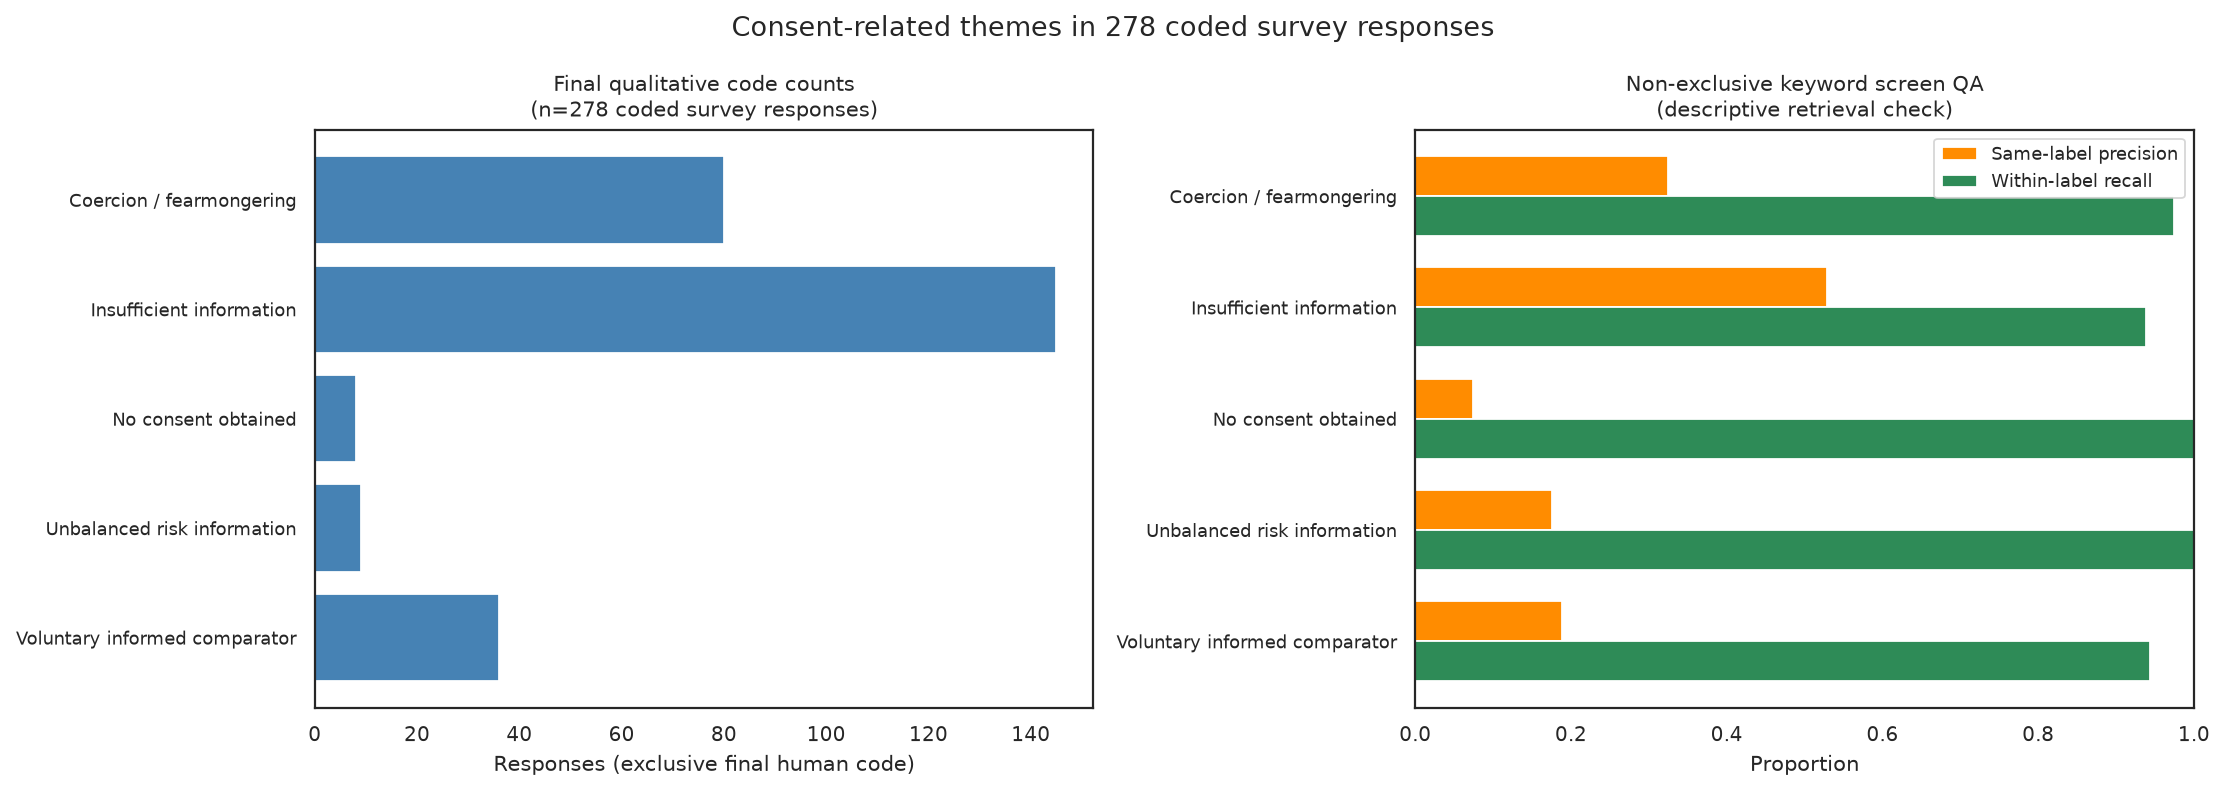

Human-code counts and non-exclusive keyword hits are intentionally not plotted as comparable totals.


In [11]:
# ── Figure 4: keep exclusive code counts separate from non-exclusive screen QA ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_map = {
    'Coercion and fearmongering': 'Coercion / fearmongering',
    'Insufficient information about risks and alternatives': 'Insufficient information',
    'Procedures performed without consent': 'No consent obtained',
    'Anxiety caused by unbalanced risk information': 'Unbalanced risk information',
    'Voluntary and informed decision-making': 'Voluntary informed comparator',
}
labels = [label_map[t] for t in prev_df['Theme']]
y = np.arange(len(prev_df))
axes[0].barh(y, prev_df['Qualitative n'], color='steelblue')
axes[0].set_yticks(y); axes[0].set_yticklabels(labels, fontsize=8); axes[0].invert_yaxis()
axes[0].set_xlabel('Responses (exclusive final human code)')
axes[0].set_title(f'Final qualitative code counts\n(n={n_total} coded survey responses)')

precision = prev_df['Crude same-label precision'].fillna(0)
recall = prev_df['Within-label hit recall'].fillna(0)
height = .36
axes[1].barh(y - height/2, precision, height, label='Same-label precision', color='darkorange')
axes[1].barh(y + height/2, recall, height, label='Within-label recall', color='seagreen')
axes[1].set_yticks(y); axes[1].set_yticklabels(labels, fontsize=8); axes[1].invert_yaxis()
axes[1].set_xlim(0, 1); axes[1].set_xlabel('Proportion')
axes[1].set_title('Non-exclusive keyword screen QA\n(descriptive retrieval check)')
axes[1].legend(fontsize=8)
fig.suptitle('Consent-related themes in 278 coded survey responses', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_problem_themes.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig4_problem_themes.png', dpi=200, bbox_inches='tight')
plt.show()
print('Human-code counts and non-exclusive keyword hits are intentionally not plotted as comparable totals.')


## 7. Final summary — thesis findings at a glance

In [12]:
print('\n' + '█'*80)
print('  THESIS FINDINGS SUMMARY')
print('█'*80)

five_class = comparison_df[comparison_df['Task'] == '5-class decision-making'].sort_values('Macro F1', ascending=False)
best = five_class.iloc[0]

print('')
print('RESEARCH QUESTION 1 — Reproducibility')
print('Can NLP reproduce qualitative codes from the HSE consent framework?')
print('')
print(f"  Answer: Partially. The strongest current model is {best['Method']}, with")
print("  Cohen's kappa = {}, macro-precision = {}, macro-recall = {}, and macro-F1 = {}.".format(best["Cohen's κ"], best['Macro Precision'], best['Macro Recall'], best["Macro F1"]))
print(f"  Weighted precision = {best['Weighted Precision']}, weighted recall = {best['Weighted Recall']}, and weighted-F1 = {best['Weighted F1']} on the 5-class decision-making task.")
print('  Performance is strongest for better-represented classes and remains limited')
print('  for rare, context-dependent codes such as no_consent and too_much_info.')
print('')
print('RESEARCH QUESTION 2 — Interpretability')
print('Do SHAP and LIME explain NLP predictions in terms meaningful to qualitative researchers?')
print('')
print('  Answer: The interpretability analysis is now phrase-aware. Notebook 03_0')
print('  extracts broad candidate consent phrases systematically from the corpus, and')
print('  Notebook 03_1 scores phrase-code association directly from human labels,')
print('  while revised Notebook 03 uses one broad 2-4 gram candidate vocabulary for LIME,')
print('  phrase-level SHAP, and human evidence, enabling like-for-like comparison.')
print('  Local explanations target the saved final model prediction, not the human class.')
print('  They are direct OOF-error explanations only when the final prediction matches')
print('  the saved OOF prediction; otherwise they are labelled proxy-only.')
print(f'  Full-corpus LIME/SHAP comparison covers {len(agreement_df) if HAS_INTERP else 0}/278 responses.')
print('  Agreement/disagreement between human-code evidence, LIME, and SHAP is treated')
print('  as a human-review signal, not as proof of correctness.')
print('')
print('POLICY FINDINGS — Problems in Irish IOL care')
print('  The working labels and extracted phrases support a human-in-the-loop reading')
print('  of coercion, information gaps, unconsented procedures, and unbalanced risk')
print('  communication. NLP helps surface candidate responses and non-exclusive phrase hits, but the')
print('  final policy interpretation remains grounded in qualitative judgement.')

print('All outputs saved to:', OUTPUT_DIR.absolute())
print('\nFiles for thesis/tooling:')
for f in sorted(OUTPUT_DIR.glob('fig*.p*')):
    print(f'  {f.name}')
for name in ['method_comparison_table.csv', 'method_convergence.csv', 'best_method_per_class_metrics.csv', 'interpretability_review_summary.csv', 'triangulation_pattern_summary.csv', 'triangulation_pattern_wide.csv', 'triangulated_phrase_evidence.csv', 'problem_theme_prevalence.csv', 'tool_design.json', 'streamlit_tool.py']:
    print(f'  {name}')



████████████████████████████████████████████████████████████████████████████████
  THESIS FINDINGS SUMMARY
████████████████████████████████████████████████████████████████████████████████

RESEARCH QUESTION 1 — Reproducibility
Can NLP reproduce qualitative codes from the HSE consent framework?

  Answer: Partially. The strongest current model is SetFit MPNet stronger semantic baseline 5-fold CV, with
  Cohen's kappa = 0.607, macro-precision = 0.829, macro-recall = 0.659, and macro-F1 = 0.711.
  Weighted precision = 0.768, weighted recall = 0.763, and weighted-F1 = 0.758 on the 5-class decision-making task.
  Performance is strongest for better-represented classes and remains limited
  for rare, context-dependent codes such as no_consent and too_much_info.

RESEARCH QUESTION 2 — Interpretability
Do SHAP and LIME explain NLP predictions in terms meaningful to qualitative researchers?

  Answer: The interpretability analysis is now phrase-aware. Notebook 03_0
  extracts broad candidate c